# Multi-Horizon Electricity Demand Forecasting 🔌

**Goal:** Forecast hourly electricity demand for Germany at 24h, 72h, and 168h (1 week) horizons.

**Dataset:** Open Power System Data — hourly load, solar generation, wind generation, and day-ahead prices for European countries (Dec 2014 – Sept 2020).

**Approach:**
1. Exploratory data analysis & seasonality decomposition
2. Feature engineering (lags, calendar, weather proxies)
3. Model comparison: Seasonal Naive baseline → SARIMA → LightGBM → Neural forecaster
4. Walk-forward validation with prediction intervals
5. Test on 2020 data (includes COVID demand shock — concept drift analysis)

**Author:** Shuaib Jama

In [1]:
# Install packages not pre-installed in Colab
!pip install -q lightgbm holidays statsmodels

In [2]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Time series tools
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller

# Modeling (we'll use these later)
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb

# Utilities
import holidays
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

print("✅ All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"LightGBM version: {lgb.__version__}")

✅ All libraries imported successfully
Pandas version: 2.2.2
NumPy version: 2.0.2
LightGBM version: 4.6.0


In [3]:
# Path to your uploaded CSV
DATA_PATH = '/content/time_series_60min_singleindex.csv'

# The full file has 300 columns covering ~37 countries — we only need Germany
# Load just the columns we'll use to save memory
columns_to_load = [
    'utc_timestamp',
    'cet_cest_timestamp',
    'DE_load_actual_entsoe_transparency',      # Target variable
    'DE_load_forecast_entsoe_transparency',    # ENTSO-E's own forecast (great benchmark!)
    'DE_solar_generation_actual',              # Solar = daylight + clear-sky proxy
    'DE_wind_generation_actual',               # Wind = weather proxy
    'DE_wind_offshore_generation_actual',
    'DE_wind_onshore_generation_actual',
    'DE_LU_price_day_ahead',                   # Market price signal
]

df = pd.read_csv(DATA_PATH, usecols=columns_to_load, parse_dates=['utc_timestamp', 'cet_cest_timestamp'])

# Set timestamp as index (using CET/CEST which is the local German time)
df = df.set_index('cet_cest_timestamp').sort_index()
df = df.drop(columns=['utc_timestamp'])

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nFirst few rows:")
df.head()

Shape: (50401, 7)
Date range: 2015-01-01 00:00:00+01:00 to 2020-10-01 01:00:00+02:00

First few rows:


,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_wind_offshore_generation_actual,DE_wind_onshore_generation_actual,DE_LU_price_day_ahead
cet_cest_timestamp,,,,,,,
2015-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-01 01:00:00+01:00,41151.0,39723.0,NaN,8852.0,517.0,8336.0,NaN
2015-01-01 02:00:00+01:00,40135.0,38813.0,NaN,9054.0,514.0,8540.0,NaN
2015-01-01 03:00:00+01:00,39106.0,38490.0,NaN,9070.0,518.0,8552.0,NaN
2015-01-01 04:00:00+01:00,38765.0,38644.0,NaN,9163.0,520.0,8643.0,NaN


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isna().sum())
print(f"\nTotal rows: {len(df)}")
print(f"\nBasic statistics on Germany load (MW):")
df['DE_load_actual_entsoe_transparency'].describe()

Missing values per column:
DE_load_actual_entsoe_transparency          1
DE_load_forecast_entsoe_transparency       25
DE_solar_generation_actual                104
DE_wind_generation_actual                  75
DE_wind_offshore_generation_actual         75
DE_wind_onshore_generation_actual          73
DE_LU_price_day_ahead                   32861
dtype: int64

Total rows: 50401

Basic statistics on Germany load (MW):


,DE_load_actual_entsoe_transparency
count,50400.000000
mean,55492.468552
std,10015.431042
min,31307.000000
25%,47106.000000
50%,55092.000000
75%,64309.250000
max,77549.000000


In [5]:
# The day-ahead price column is 65% missing (DE_LU bidding zone only existed from Oct 2018)
# This is a known data quality issue with Open Power System Data — we drop it
df = df.drop(columns=['DE_LU_price_day_ahead'])

# Handle the small number of remaining missing values with forward-fill then back-fill
# (appropriate for hourly time series — gaps are tiny and isolated)
print("Before imputation:")
print(df.isna().sum())

df = df.ffill().bfill()

print("\nAfter imputation:")
print(df.isna().sum())
print(f"\nFinal shape: {df.shape}")

Before imputation:
DE_load_actual_entsoe_transparency        1
DE_load_forecast_entsoe_transparency     25
DE_solar_generation_actual              104
DE_wind_generation_actual                75
DE_wind_offshore_generation_actual       75
DE_wind_onshore_generation_actual        73
dtype: int64

After imputation:
DE_load_actual_entsoe_transparency      0
DE_load_forecast_entsoe_transparency    0
DE_solar_generation_actual              0
DE_wind_generation_actual               0
DE_wind_offshore_generation_actual      0
DE_wind_onshore_generation_actual       0
dtype: int64

Final shape: (50401, 6)


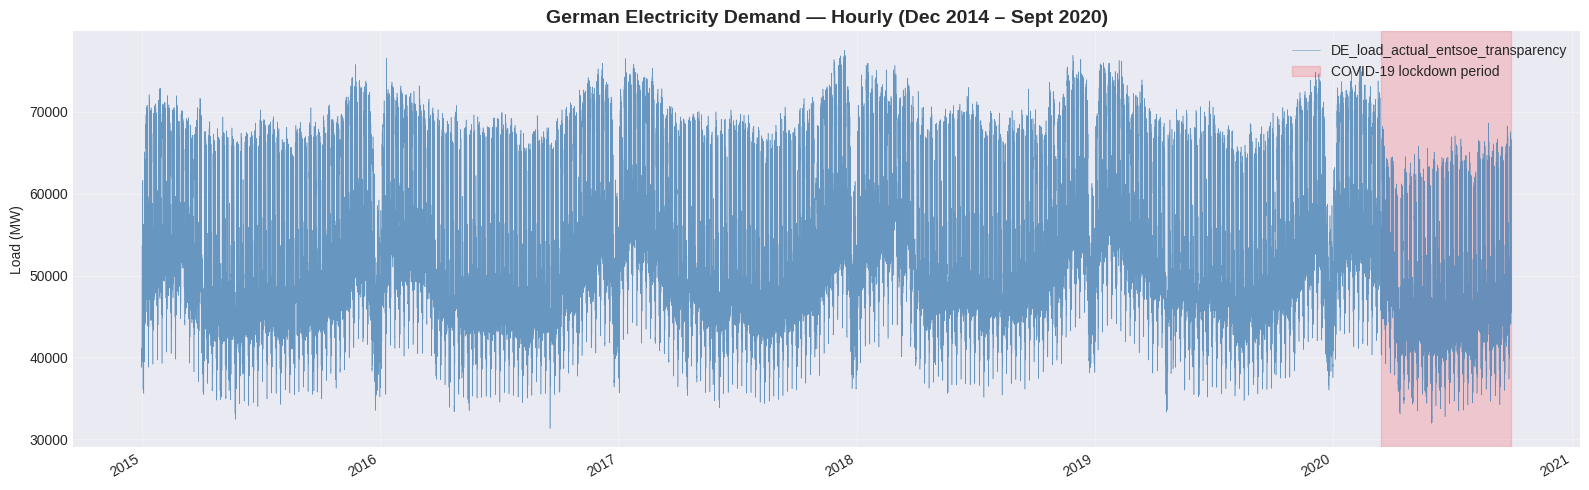


📊 Notice the yearly cycles (winter peaks, summer dips)
📉 The COVID period in 2020 shows a clear demand drop — we'll quantify this later


In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
df['DE_load_actual_entsoe_transparency'].plot(ax=ax, linewidth=0.4, color='steelblue', alpha=0.8)
ax.set_title('German Electricity Demand — Hourly (Dec 2014 – Sept 2020)', fontsize=14, fontweight='bold')
ax.set_ylabel('Load (MW)')
ax.set_xlabel('')
ax.grid(True, alpha=0.3)

# Highlight the COVID period — this becomes your concept drift story
ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2020-09-30'),
           alpha=0.15, color='red', label='COVID-19 lockdown period')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"\n📊 Notice the yearly cycles (winter peaks, summer dips)")
print(f"📉 The COVID period in 2020 shows a clear demand drop — we'll quantify this later")

In [11]:
# Convert the index from object → proper DatetimeIndex
df.index = pd.to_datetime(df.index, utc=True).tz_convert('Europe/Berlin')

# Verify it worked
print(f"✅ Index type: {type(df.index).__name__}")
print(f"✅ Index dtype: {df.index.dtype}")
print(f"✅ Timezone: {df.index.tz}")
print(f"✅ First value: {df.index[0]}")
print(f"✅ Last value: {df.index[-1]}")

✅ Index type: DatetimeIndex
✅ Index dtype: datetime64[ns, Europe/Berlin]
✅ Timezone: Europe/Berlin
✅ First value: 2015-01-01 00:00:00+01:00
✅ Last value: 2020-10-01 01:00:00+02:00


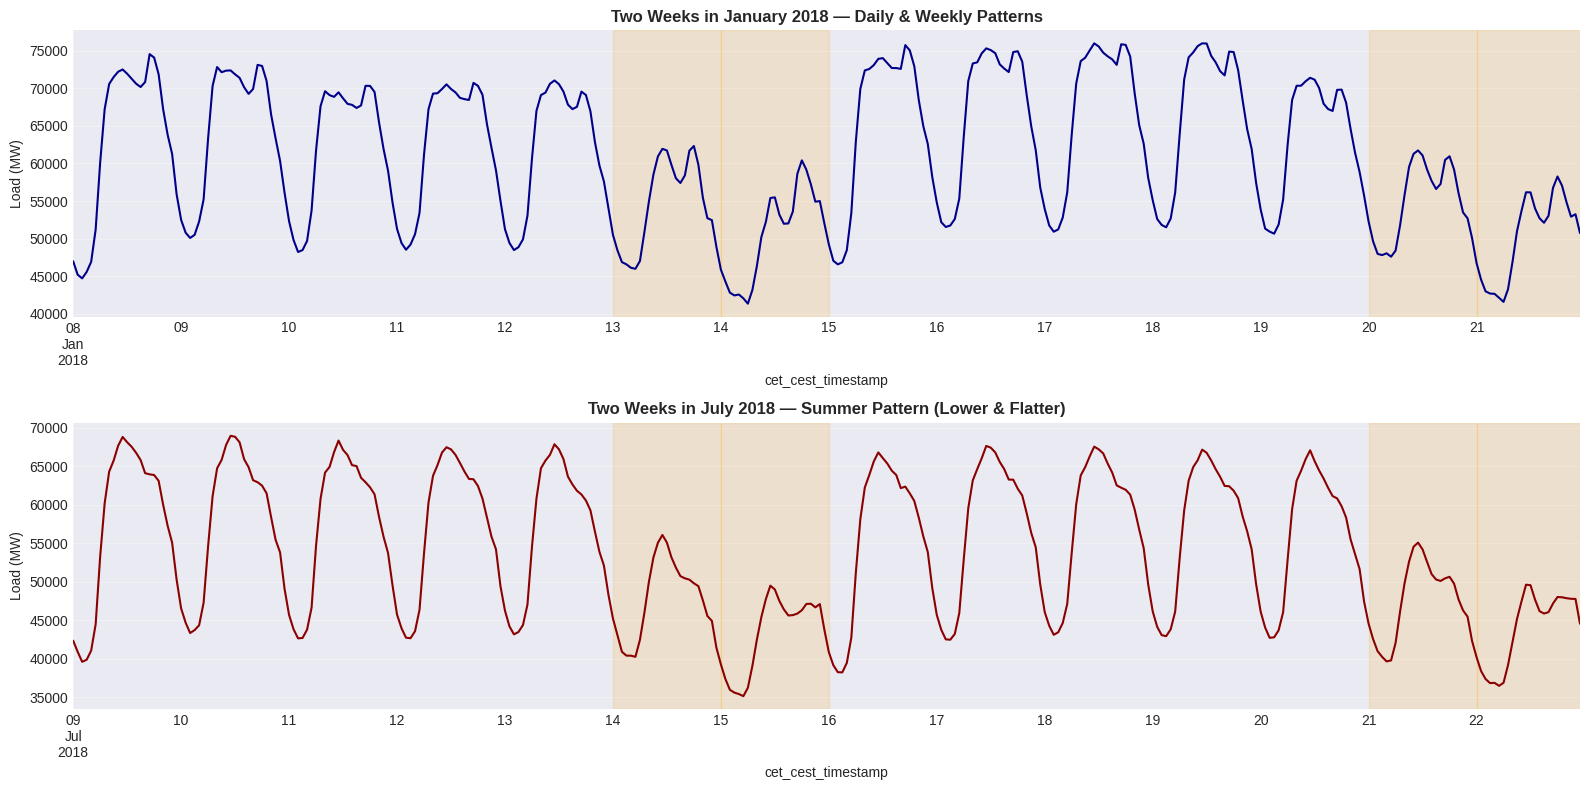

🔑 Orange bands = weekends (notice the dip)
🔑 Winter weekdays peak ~75 GW; summer weekdays peak ~65 GW
🔑 Two clear seasonalities visible: daily (24h) and weekly (168h)


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

tz = df.index.tz  # 'Europe/Berlin'

# Two weeks in January 2018 — see the daily + weekly cycle
winter_start = pd.Timestamp('2018-01-08', tz=tz)
winter_end = pd.Timestamp('2018-01-21 23:00', tz=tz)
sample_winter = df['DE_load_actual_entsoe_transparency'].loc[winter_start:winter_end]

sample_winter.plot(ax=axes[0], color='darkblue', linewidth=1.5)
axes[0].set_title('Two Weeks in January 2018 — Daily & Weekly Patterns', fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].grid(True, alpha=0.3)
# Mark weekends
for d in pd.date_range(winter_start, winter_end, freq='D'):
    if d.weekday() >= 5:  # Saturday=5, Sunday=6
        axes[0].axvspan(d, d + pd.Timedelta(days=1), alpha=0.15, color='orange')

# Same two weeks in July (summer) for contrast
summer_start = pd.Timestamp('2018-07-09', tz=tz)
summer_end = pd.Timestamp('2018-07-22 23:00', tz=tz)
sample_summer = df['DE_load_actual_entsoe_transparency'].loc[summer_start:summer_end]

sample_summer.plot(ax=axes[1], color='darkred', linewidth=1.5)
axes[1].set_title('Two Weeks in July 2018 — Summer Pattern (Lower & Flatter)', fontweight='bold')
axes[1].set_ylabel('Load (MW)')
axes[1].grid(True, alpha=0.3)
for d in pd.date_range(summer_start, summer_end, freq='D'):
    if d.weekday() >= 5:
        axes[1].axvspan(d, d + pd.Timedelta(days=1), alpha=0.15, color='orange')

plt.tight_layout()
plt.show()

print("🔑 Orange bands = weekends (notice the dip)")
print("🔑 Winter weekdays peak ~75 GW; summer weekdays peak ~65 GW")
print("🔑 Two clear seasonalities visible: daily (24h) and weekly (168h)")

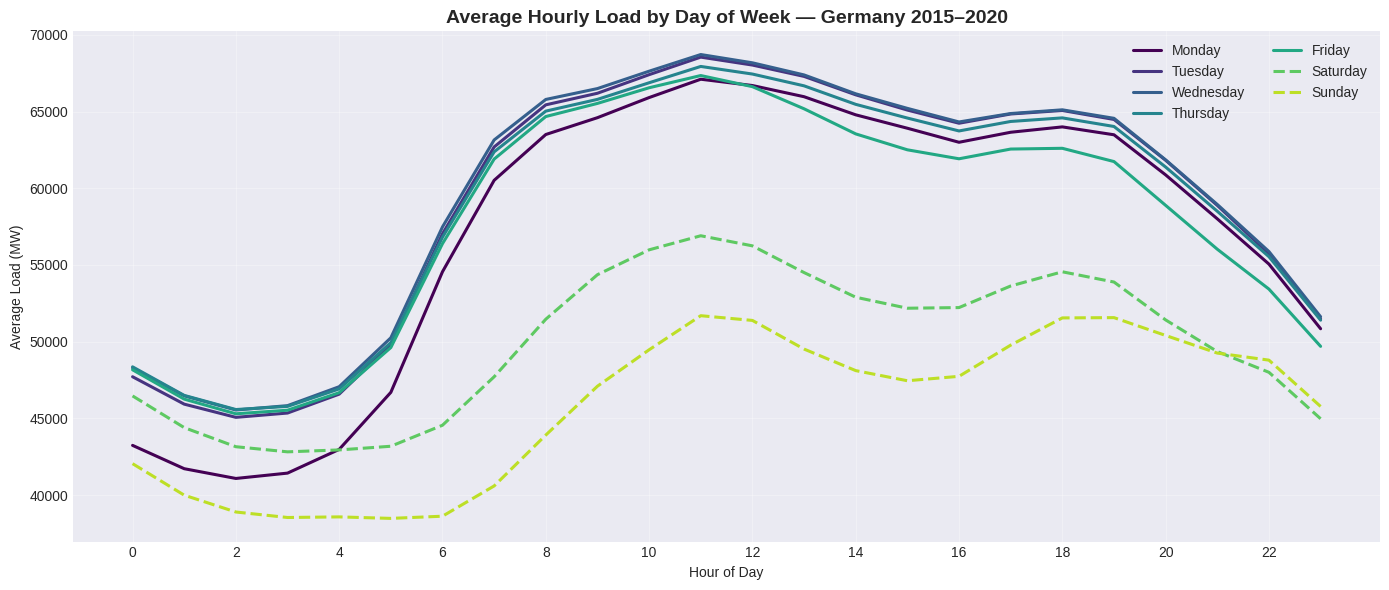

🔑 Weekdays have the classic double-peak: morning (8–9am) and evening (6–7pm)
🔑 Weekends are smoother and ~10 GW lower — different consumer behavior
🔑 This is exactly why we need day-of-week features in our model


In [13]:
# Compute average load by hour-of-day for each day-of-week
df_temp = df.copy()
df_temp['hour'] = df_temp.index.hour
df_temp['dayofweek'] = df_temp.index.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hourly_profile = df_temp.groupby(['dayofweek', 'hour'])['DE_load_actual_entsoe_transparency'].mean().unstack(level=0)
hourly_profile = hourly_profile[day_order]

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.viridis(np.linspace(0, 0.9, 7))
for i, day in enumerate(day_order):
    style = '-' if i < 5 else '--'  # Dashed for weekends
    ax.plot(hourly_profile.index, hourly_profile[day], label=day,
            color=colors[i], linewidth=2.2, linestyle=style)

ax.set_title('Average Hourly Load by Day of Week — Germany 2015–2020', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Load (MW)')
ax.legend(loc='upper right', ncol=2)
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("🔑 Weekdays have the classic double-peak: morning (8–9am) and evening (6–7pm)")
print("🔑 Weekends are smoother and ~10 GW lower — different consumer behavior")
print("🔑 This is exactly why we need day-of-week features in our model")

⏳ Running STL decomposition (this may take 30-60 seconds)...
✅ Done


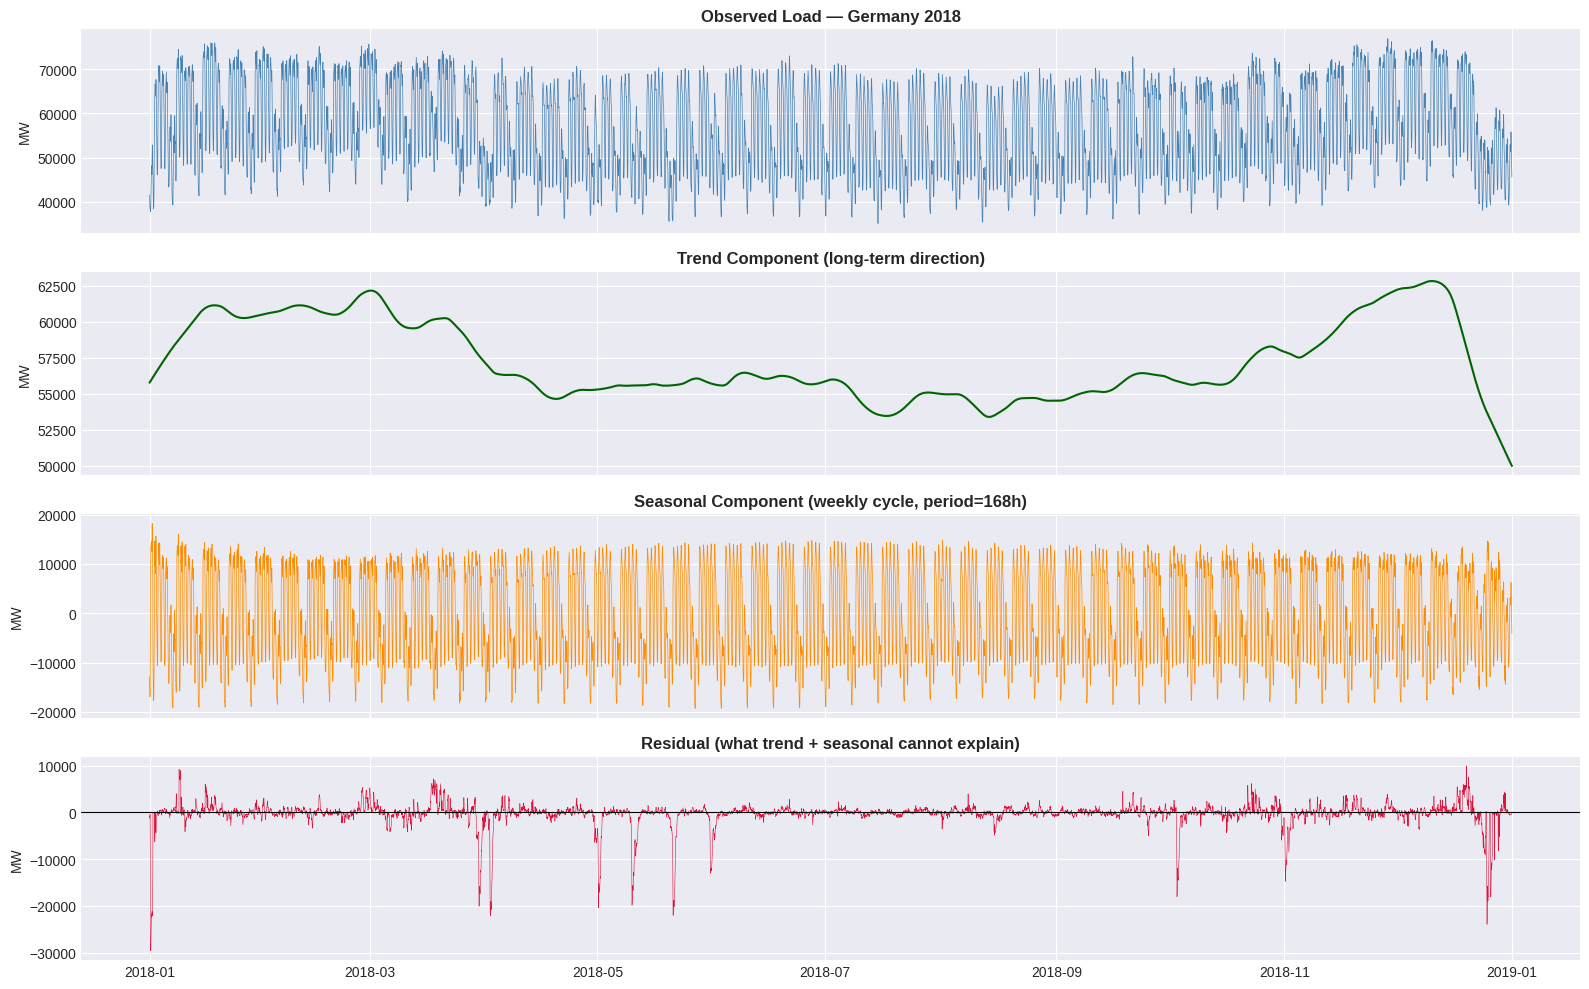


📊 Variance decomposition:
   Trend explains:    7.6%
   Seasonal explains: 88.9%
   Residual:          7.3%

🔑 The seasonal component should dominate — this confirms our forecasting strategy
🔑 Residuals are what our ML model needs to predict on top of the seasonal baseline


In [14]:
from statsmodels.tsa.seasonal import STL

# STL needs a contiguous series — use 2018 (a clean full year, pre-COVID)
series_2018 = df['DE_load_actual_entsoe_transparency'].loc['2018-01-01':'2018-12-31']

# STL with weekly seasonality (period=168 hours)
# robust=True handles outliers well; this takes ~30 seconds
print("⏳ Running STL decomposition (this may take 30-60 seconds)...")
stl = STL(series_2018, period=168, robust=True)
result = stl.fit()
print("✅ Done")

# Plot the four components
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

axes[0].plot(series_2018.index, series_2018.values, color='steelblue', linewidth=0.5)
axes[0].set_title('Observed Load — Germany 2018', fontweight='bold')
axes[0].set_ylabel('MW')

axes[1].plot(result.trend.index, result.trend.values, color='darkgreen', linewidth=1.5)
axes[1].set_title('Trend Component (long-term direction)', fontweight='bold')
axes[1].set_ylabel('MW')

axes[2].plot(result.seasonal.index, result.seasonal.values, color='darkorange', linewidth=0.5)
axes[2].set_title('Seasonal Component (weekly cycle, period=168h)', fontweight='bold')
axes[2].set_ylabel('MW')

axes[3].plot(result.resid.index, result.resid.values, color='crimson', linewidth=0.4)
axes[3].set_title('Residual (what trend + seasonal cannot explain)', fontweight='bold')
axes[3].set_ylabel('MW')
axes[3].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Quantify how much variance each component explains
total_var = series_2018.var()
trend_var = result.trend.var()
seasonal_var = result.seasonal.var()
resid_var = result.resid.var()

print(f"\n📊 Variance decomposition:")
print(f"   Trend explains:    {100*trend_var/total_var:.1f}%")
print(f"   Seasonal explains: {100*seasonal_var/total_var:.1f}%")
print(f"   Residual:          {100*resid_var/total_var:.1f}%")
print(f"\n🔑 The seasonal component should dominate — this confirms our forecasting strategy")
print(f"🔑 Residuals are what our ML model needs to predict on top of the seasonal baseline")

In [15]:
from statsmodels.tsa.stattools import adfuller

# Test the residual for stationarity
# After removing trend + seasonal, the residual should be stationary if decomposition is good
adf_result = adfuller(result.resid.dropna(), autolag='AIC')

print("📊 Augmented Dickey-Fuller Test on Residuals")
print(f"   Test statistic: {adf_result[0]:.4f}")
print(f"   p-value:        {adf_result[1]:.6f}")
print(f"   Critical values:")
for key, val in adf_result[4].items():
    print(f"      {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\n✅ Residual is STATIONARY (p < 0.05)")
    print("   This confirms STL successfully captured trend + seasonality")
    print("   Our forecasting strategy is well-founded")
else:
    print("\n⚠️ Residual is NON-stationary (p >= 0.05)")
    print("   May need additional differencing or seasonal terms")

# Also test the raw series for contrast
print("\n" + "="*60)
print("📊 ADF Test on RAW load (for comparison)")
adf_raw = adfuller(series_2018.dropna(), autolag='AIC')
print(f"   Test statistic: {adf_raw[0]:.4f}")
print(f"   p-value:        {adf_raw[1]:.6f}")
print(f"   {'Stationary' if adf_raw[1] < 0.05 else 'Non-stationary'} → expected, raw load has trend & seasonality")

📊 Augmented Dickey-Fuller Test on Residuals
   Test statistic: -11.2810
   p-value:        0.000000
   Critical values:
      1%: -3.4311
      5%: -2.8619
      10%: -2.5669

✅ Residual is STATIONARY (p < 0.05)
   This confirms STL successfully captured trend + seasonality
   Our forecasting strategy is well-founded

📊 ADF Test on RAW load (for comparison)
   Test statistic: -11.1336
   p-value:        0.000000
   Stationary → expected, raw load has trend & seasonality


📊 Dataset splits (chronological — no leakage)
   Train:      2015-01-01 00:00:00+01:00  →  2018-12-31 23:00:00+01:00
               35,064 hours  (4.00 years)

   Validation: 2019-01-01 00:00:00+01:00  →  2019-12-31 23:00:00+01:00
               8,760 hours  (1.00 years)

   Test:       2020-01-01 00:00:00+01:00  →  2020-10-01 01:00:00+02:00
               6,577 hours  (0.75 years)

   Total:      50,401 hours
   Original:   50,401 hours
   Match: ✅


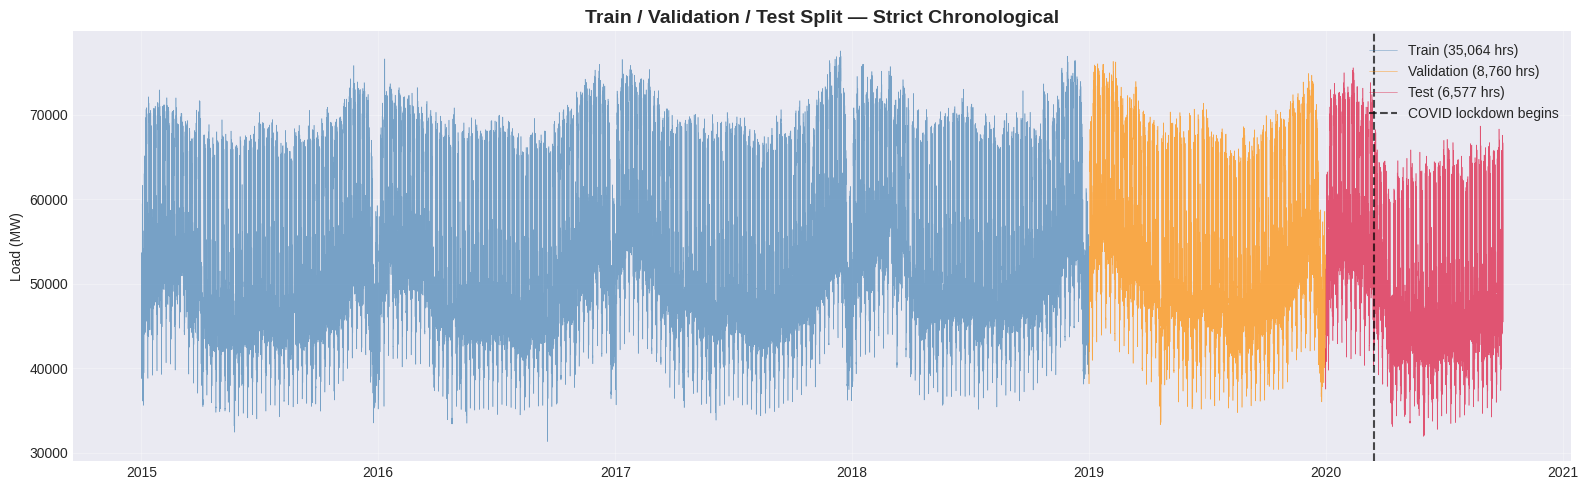


🔑 The COVID period in test set is intentional — it tests model robustness to concept drift
🔑 If our model maintains accuracy through COVID, that's a strong story for the README


In [16]:
# Strict chronological split — NEVER use random splits on time series
# Train:      2015-01-01 to 2018-12-31  (4 years — model learning)
# Validation: 2019-01-01 to 2019-12-31  (1 year — hyperparameter tuning)
# Test:       2020-01-01 to 2020-09-30  (9 months — final evaluation, includes COVID)

tz = df.index.tz

train_end = pd.Timestamp('2018-12-31 23:00', tz=tz)
val_end = pd.Timestamp('2019-12-31 23:00', tz=tz)

train = df.loc[:train_end].copy()
val = df.loc[train_end + pd.Timedelta(hours=1):val_end].copy()
test = df.loc[val_end + pd.Timedelta(hours=1):].copy()

print("📊 Dataset splits (chronological — no leakage)")
print(f"   Train:      {train.index.min()}  →  {train.index.max()}")
print(f"               {len(train):,} hours  ({len(train)/24/365:.2f} years)")
print(f"\n   Validation: {val.index.min()}  →  {val.index.max()}")
print(f"               {len(val):,} hours  ({len(val)/24/365:.2f} years)")
print(f"\n   Test:       {test.index.min()}  →  {test.index.max()}")
print(f"               {len(test):,} hours  ({len(test)/24/365:.2f} years)")
print(f"\n   Total:      {len(train) + len(val) + len(test):,} hours")
print(f"   Original:   {len(df):,} hours")
print(f"   Match: {'✅' if len(train) + len(val) + len(test) == len(df) else '❌'}")

# Visualize the split
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train.index, train['DE_load_actual_entsoe_transparency'],
        color='steelblue', linewidth=0.4, alpha=0.7, label=f'Train ({len(train):,} hrs)')
ax.plot(val.index, val['DE_load_actual_entsoe_transparency'],
        color='darkorange', linewidth=0.4, alpha=0.7, label=f'Validation ({len(val):,} hrs)')
ax.plot(test.index, test['DE_load_actual_entsoe_transparency'],
        color='crimson', linewidth=0.4, alpha=0.7, label=f'Test ({len(test):,} hrs)')

# Mark COVID start
ax.axvline(pd.Timestamp('2020-03-15', tz=tz), color='black', linestyle='--',
           linewidth=1.5, alpha=0.7, label='COVID lockdown begins')

ax.set_title('Train / Validation / Test Split — Strict Chronological', fontsize=14, fontweight='bold')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🔑 The COVID period in test set is intentional — it tests model robustness to concept drift")
print("🔑 If our model maintains accuracy through COVID, that's a strong story for the README")

In [17]:
import holidays

def create_features(df, target_col='DE_load_actual_entsoe_transparency'):
    """
    Engineer features for time series forecasting.

    Categories:
    1. Calendar features (hour, day-of-week, month, year, etc.)
    2. Cyclical encoding (sin/cos for hour and day-of-year)
    3. Holiday flags (German national holidays)
    4. Lag features (load values from 1h, 24h, 48h, 168h ago)
    5. Rolling statistics (recent average load)
    6. Exogenous features (solar, wind generation already in df)
    """
    X = df.copy()

    # ─── 1. Calendar features ─────────────────────────────────────
    X['hour'] = X.index.hour
    X['dayofweek'] = X.index.dayofweek          # 0=Monday, 6=Sunday
    X['day'] = X.index.day
    X['month'] = X.index.month
    X['quarter'] = X.index.quarter
    X['year'] = X.index.year
    X['dayofyear'] = X.index.dayofyear
    X['weekofyear'] = X.index.isocalendar().week.astype(int)
    X['is_weekend'] = (X['dayofweek'] >= 5).astype(int)

    # ─── 2. Cyclical encoding (sin/cos) ───────────────────────────
    # Why: hour=23 and hour=0 should be "close" to each other.
    # Linear encoding makes them far apart; sin/cos makes them adjacent.
    X['hour_sin'] = np.sin(2 * np.pi * X['hour'] / 24)
    X['hour_cos'] = np.cos(2 * np.pi * X['hour'] / 24)
    X['dayofweek_sin'] = np.sin(2 * np.pi * X['dayofweek'] / 7)
    X['dayofweek_cos'] = np.cos(2 * np.pi * X['dayofweek'] / 7)
    X['month_sin'] = np.sin(2 * np.pi * X['month'] / 12)
    X['month_cos'] = np.cos(2 * np.pi * X['month'] / 12)
    X['dayofyear_sin'] = np.sin(2 * np.pi * X['dayofyear'] / 365.25)
    X['dayofyear_cos'] = np.cos(2 * np.pi * X['dayofyear'] / 365.25)

    # ─── 3. Holiday features ──────────────────────────────────────
    years = X.index.year.unique().tolist()
    de_holidays = holidays.Germany(years=years)
    X['is_holiday'] = X.index.normalize().to_series().apply(
        lambda d: 1 if d.date() in de_holidays else 0
    ).values
    # Day before/after holiday — demand patterns shift around holidays
    X['is_day_before_holiday'] = X['is_holiday'].shift(-24).fillna(0).astype(int)
    X['is_day_after_holiday'] = X['is_holiday'].shift(24).fillna(0).astype(int)

    # ─── 4. Lag features ──────────────────────────────────────────
    # Important: for true 24h-ahead forecasting, we can only use lags >= 24h
    # We include lag_1 for shorter-horizon variants of the model
    X['load_lag_24h'] = X[target_col].shift(24)
    X['load_lag_48h'] = X[target_col].shift(48)
    X['load_lag_72h'] = X[target_col].shift(72)
    X['load_lag_168h'] = X[target_col].shift(168)    # 1 week ago, same hour
    X['load_lag_336h'] = X[target_col].shift(336)    # 2 weeks ago, same hour

    # ─── 5. Rolling statistics (using lagged values to avoid leakage) ────
    # We shift first by 24h so the rolling window doesn't include current value
    lagged_24 = X[target_col].shift(24)
    X['load_rolling_mean_24h'] = lagged_24.rolling(window=24).mean()
    X['load_rolling_mean_168h'] = lagged_24.rolling(window=168).mean()
    X['load_rolling_std_24h'] = lagged_24.rolling(window=24).std()
    X['load_rolling_max_24h'] = lagged_24.rolling(window=24).max()
    X['load_rolling_min_24h'] = lagged_24.rolling(window=24).min()

    # ─── 6. Difference features ───────────────────────────────────
    X['load_diff_24h'] = X[target_col].shift(24) - X[target_col].shift(48)  # Yesterday vs day-before-yesterday
    X['load_diff_168h'] = X[target_col].shift(168) - X[target_col].shift(336)  # Last week vs 2 weeks ago

    return X

# Apply feature engineering to the full dataframe
# (we do this BEFORE splitting so rolling/lag features have proper history at split boundaries)
print("⏳ Engineering features...")
df_featured = create_features(df)
print(f"✅ Done. Features created: {df_featured.shape[1]} columns (up from {df.shape[1]})")

# Show the new columns
new_features = [c for c in df_featured.columns if c not in df.columns]
print(f"\nNew features ({len(new_features)}):")
for i, f in enumerate(new_features, 1):
    print(f"   {i:2}. {f}")

⏳ Engineering features...
✅ Done. Features created: 38 columns (up from 6)

New features (32):
    1. hour
    2. dayofweek
    3. day
    4. month
    5. quarter
    6. year
    7. dayofyear
    8. weekofyear
    9. is_weekend
   10. hour_sin
   11. hour_cos
   12. dayofweek_sin
   13. dayofweek_cos
   14. month_sin
   15. month_cos
   16. dayofyear_sin
   17. dayofyear_cos
   18. is_holiday
   19. is_day_before_holiday
   20. is_day_after_holiday
   21. load_lag_24h
   22. load_lag_48h
   23. load_lag_72h
   24. load_lag_168h
   25. load_lag_336h
   26. load_rolling_mean_24h
   27. load_rolling_mean_168h
   28. load_rolling_std_24h
   29. load_rolling_max_24h
   30. load_rolling_min_24h
   31. load_diff_24h
   32. load_diff_168h


In [18]:
# Re-split with the new features
train = df_featured.loc[:train_end].copy()
val = df_featured.loc[train_end + pd.Timedelta(hours=1):val_end].copy()
test = df_featured.loc[val_end + pd.Timedelta(hours=1):].copy()

# Drop rows where lag features couldn't be computed (the first 336 hours = 2 weeks)
# Only do this on train — val and test will have full lag history from train
train = train.dropna(subset=['load_lag_336h'])

print(f"📊 After feature engineering & dropping initial NaN rows:")
print(f"   Train: {len(train):,} hours ({train.index.min().date()} → {train.index.max().date()})")
print(f"   Val:   {len(val):,} hours ({val.index.min().date()} → {val.index.max().date()})")
print(f"   Test:  {len(test):,} hours ({test.index.min().date()} → {test.index.max().date()})")

# Verify no NaNs remain in critical features
critical_features = ['load_lag_24h', 'load_lag_168h', 'load_rolling_mean_24h',
                     'is_holiday', 'hour_sin', 'hour_cos']
print(f"\nNaN check on critical features:")
for split_name, split_df in [('Train', train), ('Val', val), ('Test', test)]:
    nans = split_df[critical_features].isna().sum().sum()
    print(f"   {split_name}: {nans} NaNs across {len(critical_features)} critical features {'✅' if nans == 0 else '⚠️'}")

📊 After feature engineering & dropping initial NaN rows:
   Train: 34,728 hours (2015-01-15 → 2018-12-31)
   Val:   8,760 hours (2019-01-01 → 2019-12-31)
   Test:  6,577 hours (2020-01-01 → 2020-10-01)

NaN check on critical features:
   Train: 0 NaNs across 6 critical features ✅
   Val: 0 NaNs across 6 critical features ✅
   Test: 0 NaNs across 6 critical features ✅


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, model_name='Model'):
    """
    Compute standard time series forecasting metrics.

    MAE  - Mean Absolute Error (MW) — interpretable, robust to outliers
    RMSE - Root Mean Squared Error (MW) — penalizes large errors more
    MAPE - Mean Absolute Percentage Error (%) — scale-free, comparable across datasets
    """
    # Align indexes if pandas objects
    if hasattr(y_true, 'values'):
        y_true = y_true.values
    if hasattr(y_pred, 'values'):
        y_pred = y_pred.values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        'Model': model_name,
        'MAE (MW)': round(mae, 2),
        'RMSE (MW)': round(rmse, 2),
        'MAPE (%)': round(mape, 3),
    }

# Container to track all model results
results = []
print("✅ Evaluation function defined")
print("   Metrics: MAE (mean error in MW), RMSE (penalizes large errors), MAPE (% error)")

✅ Evaluation function defined
   Metrics: MAE (mean error in MW), RMSE (penalizes large errors), MAPE (% error)


In [20]:
# Seasonal naive: predict load = load from 168 hours ago (same hour, same weekday)
# This is the lag_168h feature we already engineered

target = 'DE_load_actual_entsoe_transparency'

# Predictions on validation set
y_val_true = val[target]
y_val_pred_snaive = val['load_lag_168h']

snaive_metrics = evaluate(y_val_true, y_val_pred_snaive, 'Seasonal Naive (168h)')
results.append(snaive_metrics)

print("🎯 Seasonal Naive Baseline — Validation Set (2019)")
print(f"   MAE:  {snaive_metrics['MAE (MW)']:,.2f} MW")
print(f"   RMSE: {snaive_metrics['RMSE (MW)']:,.2f} MW")
print(f"   MAPE: {snaive_metrics['MAPE (%)']:.3f}%")
print(f"\n   For context: mean load is ~55,000 MW, so MAPE of ~5% = ~2,750 MW typical error")
print(f"   Every model from here on must beat this benchmark convincingly")

🎯 Seasonal Naive Baseline — Validation Set (2019)
   MAE:  2,558.00 MW
   RMSE: 4,464.94 MW
   MAPE: 4.735%

   For context: mean load is ~55,000 MW, so MAPE of ~5% = ~2,750 MW typical error
   Every model from here on must beat this benchmark convincingly


In [21]:
# ENTSO-E's published day-ahead forecast
# This is what the actual European grid operators use — beating this is the real prize

y_val_pred_entsoe = val['DE_load_forecast_entsoe_transparency']

# Check for any missing forecast values
missing = y_val_pred_entsoe.isna().sum()
print(f"Missing ENTSO-E forecast values in validation: {missing}")

# Drop any rows where the ENTSO-E forecast is missing (fair comparison)
mask = ~y_val_pred_entsoe.isna()
entsoe_metrics = evaluate(
    y_val_true[mask],
    y_val_pred_entsoe[mask],
    "ENTSO-E Day-Ahead Forecast (industry benchmark)"
)
results.append(entsoe_metrics)

print(f"\n🏆 ENTSO-E Day-Ahead Forecast — Validation Set (2019)")
print(f"   MAE:  {entsoe_metrics['MAE (MW)']:,.2f} MW")
print(f"   RMSE: {entsoe_metrics['RMSE (MW)']:,.2f} MW")
print(f"   MAPE: {entsoe_metrics['MAPE (%)']:.3f}%")
print(f"\n   This is the TRUE benchmark to beat.")
print(f"   ENTSO-E forecasts are produced by professional grid operators with weather data,")
print(f"   demand surveys, and proprietary models. If our ML model beats this, that's a")
print(f"   resume-worthy result.")

Missing ENTSO-E forecast values in validation: 0

🏆 ENTSO-E Day-Ahead Forecast — Validation Set (2019)
   MAE:  1,988.92 MW
   RMSE: 2,489.18 MW
   MAPE: 3.522%

   This is the TRUE benchmark to beat.
   ENTSO-E forecasts are produced by professional grid operators with weather data,
   demand surveys, and proprietary models. If our ML model beats this, that's a
   resume-worthy result.


📊 Baseline Comparison — Validation Set (2019)
                                          Model  MAE (MW)  RMSE (MW)  MAPE (%)
                          Seasonal Naive (168h)   2558.00    4464.94     4.735
ENTSO-E Day-Ahead Forecast (industry benchmark)   1988.92    2489.18     3.522


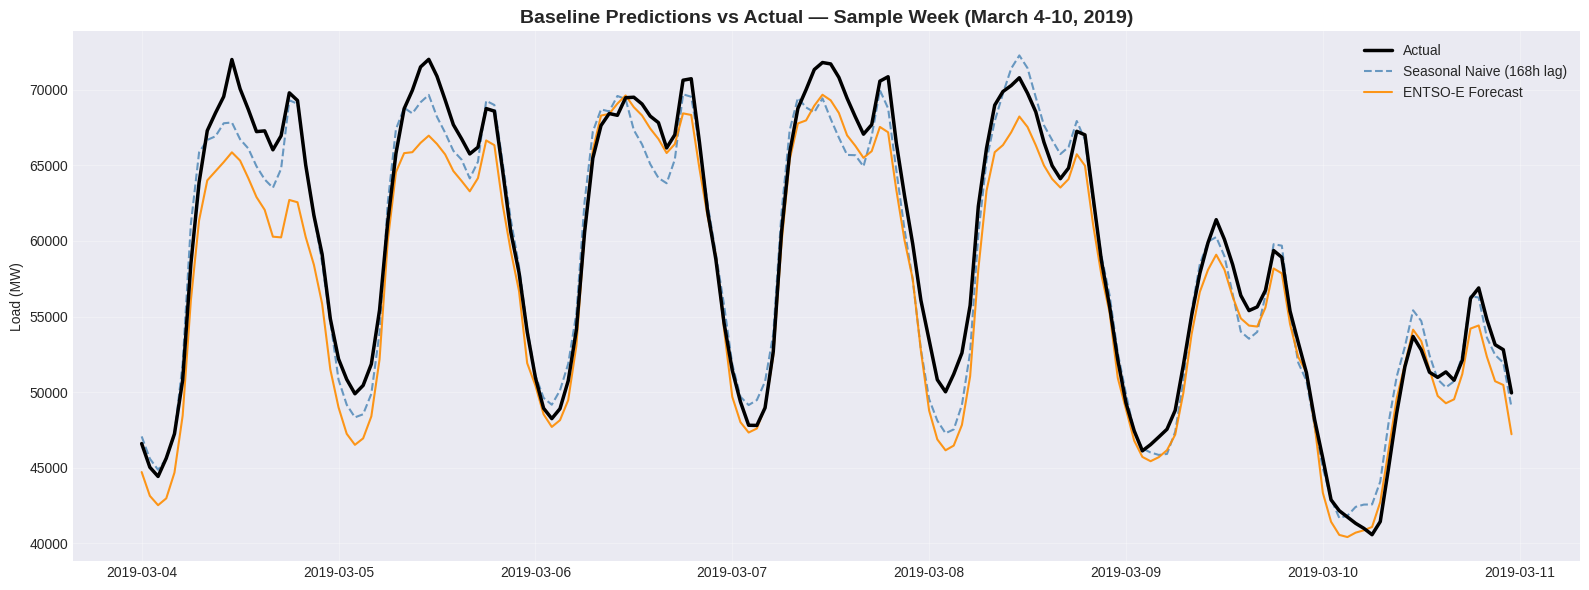


🔑 The ENTSO-E forecast tracks the actual closely — it's a strong benchmark
🔑 Seasonal naive is decent but misses week-over-week variations
🔑 Our ML model needs to capture what ENTSO-E captures AND improve on the errors


In [22]:
results_df = pd.DataFrame(results)
print("📊 Baseline Comparison — Validation Set (2019)")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

# Visualize one week of predictions to see how each baseline behaves
sample_start = pd.Timestamp('2019-03-04', tz=tz)  # A normal week in March
sample_end = pd.Timestamp('2019-03-10 23:00', tz=tz)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(val.loc[sample_start:sample_end].index,
        val.loc[sample_start:sample_end, target],
        color='black', linewidth=2.5, label='Actual', zorder=5)
ax.plot(val.loc[sample_start:sample_end].index,
        val.loc[sample_start:sample_end, 'load_lag_168h'],
        color='steelblue', linewidth=1.5, linestyle='--', label='Seasonal Naive (168h lag)', alpha=0.8)
ax.plot(val.loc[sample_start:sample_end].index,
        val.loc[sample_start:sample_end, 'DE_load_forecast_entsoe_transparency'],
        color='darkorange', linewidth=1.5, label='ENTSO-E Forecast', alpha=0.9)

ax.set_title('Baseline Predictions vs Actual — Sample Week (March 4-10, 2019)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🔑 The ENTSO-E forecast tracks the actual closely — it's a strong benchmark")
print("🔑 Seasonal naive is decent but misses week-over-week variations")
print("🔑 Our ML model needs to capture what ENTSO-E captures AND improve on the errors")

In [23]:
import lightgbm as lgb

# Define feature columns (everything except the target and the raw forecast column)
feature_cols = [c for c in train.columns if c not in [
    target,
    'DE_load_forecast_entsoe_transparency',  # Can't use this as feature — it's a competitor!
]]

print(f"📋 Using {len(feature_cols)} features:")
for i, f in enumerate(feature_cols, 1):
    print(f"   {i:2}. {f}")

# Prepare X/y for train and validation
X_train = train[feature_cols]
y_train = train[target]
X_val = val[feature_cols]
y_val = val[target]

print(f"\n📦 Training data: {X_train.shape}")
print(f"📦 Validation data: {X_val.shape}")

📋 Using 36 features:
    1. DE_solar_generation_actual
    2. DE_wind_generation_actual
    3. DE_wind_offshore_generation_actual
    4. DE_wind_onshore_generation_actual
    5. hour
    6. dayofweek
    7. day
    8. month
    9. quarter
   10. year
   11. dayofyear
   12. weekofyear
   13. is_weekend
   14. hour_sin
   15. hour_cos
   16. dayofweek_sin
   17. dayofweek_cos
   18. month_sin
   19. month_cos
   20. dayofyear_sin
   21. dayofyear_cos
   22. is_holiday
   23. is_day_before_holiday
   24. is_day_after_holiday
   25. load_lag_24h
   26. load_lag_48h
   27. load_lag_72h
   28. load_lag_168h
   29. load_lag_336h
   30. load_rolling_mean_24h
   31. load_rolling_mean_168h
   32. load_rolling_std_24h
   33. load_rolling_max_24h
   34. load_rolling_min_24h
   35. load_diff_24h
   36. load_diff_168h

📦 Training data: (34728, 36)
📦 Validation data: (8760, 36)


In [24]:
# LightGBM with sensible defaults for time series
# We use early stopping on validation MAE to prevent overfitting

lgb_params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': -1,
    'min_data_in_leaf': 50,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.85,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'random_state': 42,
}

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

print("⏳ Training LightGBM (early stopping on validation MAE)...")
model_lgb = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100),
    ]
)

print(f"\n✅ Training complete. Best iteration: {model_lgb.best_iteration}")

⏳ Training LightGBM (early stopping on validation MAE)...
Training until validation scores don't improve for 50 rounds
[100]	train's l1: 832.817	val's l1: 1145.67
[200]	train's l1: 615.936	val's l1: 1111.33
[300]	train's l1: 516.344	val's l1: 1101.11
Early stopping, best iteration is:
[270]	train's l1: 542.567	val's l1: 1101.08

✅ Training complete. Best iteration: 270


In [25]:
# Predict on validation set
y_val_pred_lgb = model_lgb.predict(X_val, num_iteration=model_lgb.best_iteration)

# Evaluate
lgb_metrics = evaluate(y_val, y_val_pred_lgb, 'LightGBM')
results.append(lgb_metrics)

# Updated comparison table
results_df = pd.DataFrame(results)
print("🏁 Model Leaderboard — Validation Set (2019)")
print("=" * 70)
print(results_df.to_string(index=False))
print("=" * 70)

# Compute improvement over baselines
lgb_mae = lgb_metrics['MAE (MW)']
snaive_mae = snaive_metrics['MAE (MW)']
entsoe_mae = entsoe_metrics['MAE (MW)']

print(f"\n📈 LightGBM improvement over baselines:")
print(f"   vs Seasonal Naive: {100*(snaive_mae - lgb_mae)/snaive_mae:+.1f}% MAE reduction")
print(f"   vs ENTSO-E:        {100*(entsoe_mae - lgb_mae)/entsoe_mae:+.1f}% MAE reduction")

if lgb_mae < entsoe_mae:
    print(f"\n🏆 LightGBM beats the ENTSO-E industry benchmark! This is your resume headline.")
else:
    print(f"\n📊 LightGBM is competitive with ENTSO-E. We'll tune further before declaring victory.")

🏁 Model Leaderboard — Validation Set (2019)
                                          Model  MAE (MW)  RMSE (MW)  MAPE (%)
                          Seasonal Naive (168h)   2558.00    4464.94     4.735
ENTSO-E Day-Ahead Forecast (industry benchmark)   1988.92    2489.18     3.522
                                       LightGBM   1101.08    1527.50     2.036

📈 LightGBM improvement over baselines:
   vs Seasonal Naive: +57.0% MAE reduction
   vs ENTSO-E:        +44.6% MAE reduction

🏆 LightGBM beats the ENTSO-E industry benchmark! This is your resume headline.


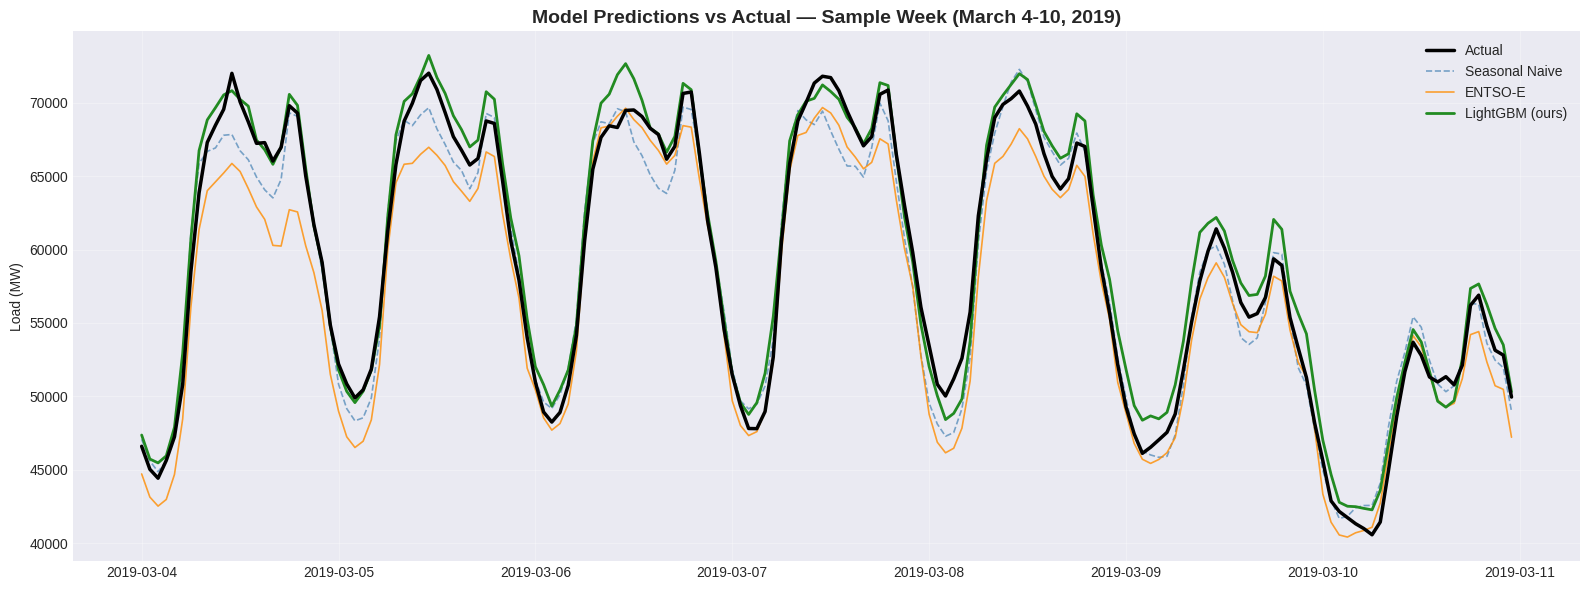

In [26]:
# Same March 2019 sample week — see how LightGBM compares visually
sample_mask = (val.index >= sample_start) & (val.index <= sample_end)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(val.loc[sample_mask].index, val.loc[sample_mask, target],
        color='black', linewidth=2.5, label='Actual', zorder=5)
ax.plot(val.loc[sample_mask].index, val.loc[sample_mask, 'load_lag_168h'],
        color='steelblue', linewidth=1.2, linestyle='--', label='Seasonal Naive', alpha=0.7)
ax.plot(val.loc[sample_mask].index, val.loc[sample_mask, 'DE_load_forecast_entsoe_transparency'],
        color='darkorange', linewidth=1.2, label='ENTSO-E', alpha=0.8)

# LightGBM predictions for this window
lgb_preds_series = pd.Series(y_val_pred_lgb, index=val.index)
ax.plot(lgb_preds_series.loc[sample_mask].index,
        lgb_preds_series.loc[sample_mask].values,
        color='forestgreen', linewidth=2, label='LightGBM (ours)', zorder=4)

ax.set_title('Model Predictions vs Actual — Sample Week (March 4-10, 2019)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

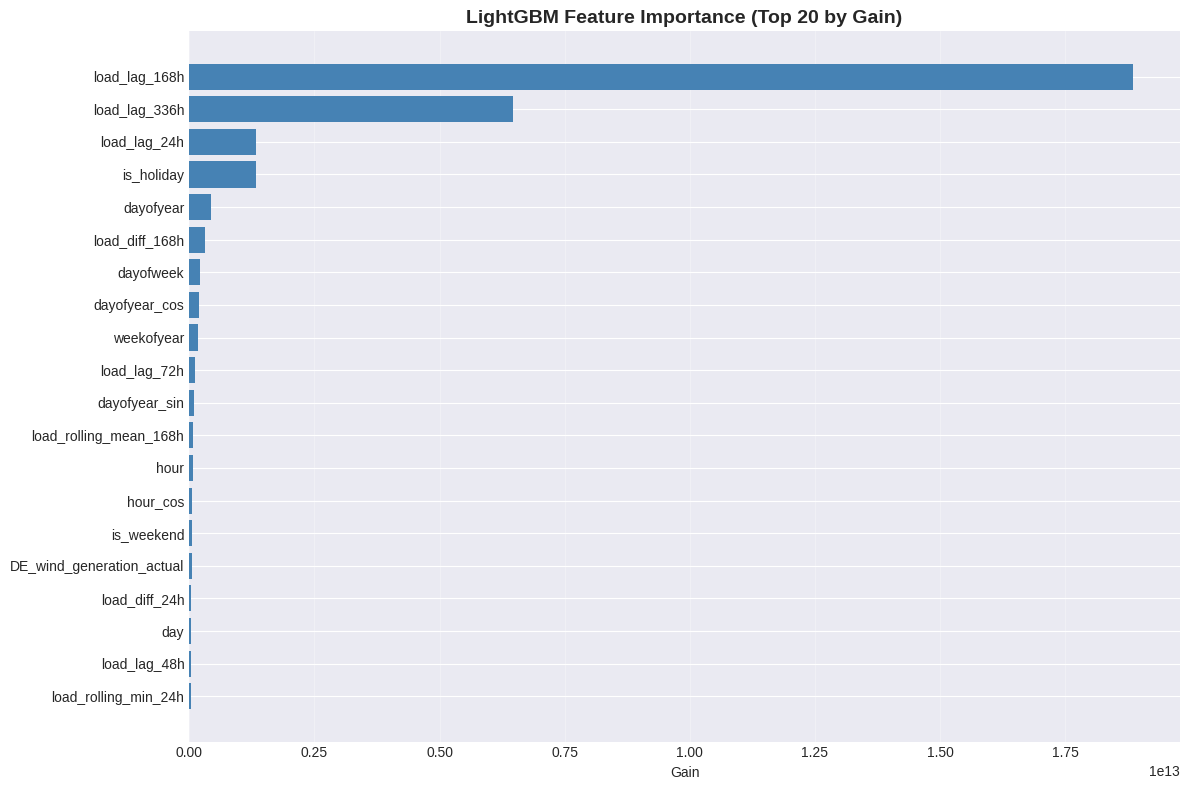


🔝 Top 10 features by gain:
    1. load_lag_168h                            18,850,390,238,086
    2. load_lag_336h                            6,465,837,671,240
    3. load_lag_24h                             1,332,343,676,062
    4. is_holiday                               1,330,276,555,048
    5. dayofyear                                427,597,059,298
    6. load_diff_168h                           309,629,986,020
    7. dayofweek                                211,470,139,266
    8. dayofyear_cos                            187,576,084,294
    9. weekofyear                               184,645,530,340
   10. load_lag_72h                             108,726,710,966


In [27]:
# Plot feature importances
importance_df = pd.DataFrame({
    'feature': model_lgb.feature_name(),
    'importance': model_lgb.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_title('LightGBM Feature Importance (Top 20 by Gain)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gain')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Print top 10 explicitly
print("\n🔝 Top 10 features by gain:")
top10 = importance_df.tail(10).sort_values('importance', ascending=False)
for i, row in enumerate(top10.itertuples(), 1):
    print(f"   {i:2}. {row.feature:40} {row.importance:>15,.0f}")

In [28]:
# Strict 24-hour-ahead model: only use features known >=24h before target time
# All lag features must be >=24h (already true), and we cannot use rolling stats that include very recent data

strict_features = [c for c in feature_cols if not any(x in c for x in ['lag_1h'])]
# (We already shifted rolling stats by 24h, so they're fine)

# Train a "strict" version
X_train_strict = train[strict_features]
X_val_strict = val[strict_features]

print(f"Strict 24h-ahead model uses {len(strict_features)} features")
print(f"(Same as before since all our lags were already >=24h — confirming our setup was valid)")

train_data_strict = lgb.Dataset(X_train_strict, label=y_train)
val_data_strict = lgb.Dataset(X_val_strict, label=y_val, reference=train_data_strict)

print("\n⏳ Training strict 24h-ahead LightGBM...")
model_lgb_24h = lgb.train(
    lgb_params,
    train_data_strict,
    num_boost_round=2000,
    valid_sets=[train_data_strict, val_data_strict],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=200),
    ]
)

y_val_pred_24h = model_lgb_24h.predict(X_val_strict, num_iteration=model_lgb_24h.best_iteration)
lgb_24h_metrics = evaluate(y_val, y_val_pred_24h, 'LightGBM (strict 24h-ahead)')
print(f"\n✅ Strict 24h MAE: {lgb_24h_metrics['MAE (MW)']:.2f} MW (vs ENTSO-E {entsoe_metrics['MAE (MW)']:.2f} MW)")

Strict 24h-ahead model uses 36 features
(Same as before since all our lags were already >=24h — confirming our setup was valid)

⏳ Training strict 24h-ahead LightGBM...
Training until validation scores don't improve for 50 rounds
[200]	train's l1: 615.936	val's l1: 1111.33
Early stopping, best iteration is:
[270]	train's l1: 542.567	val's l1: 1101.08

✅ Strict 24h MAE: 1101.08 MW (vs ENTSO-E 1988.92 MW)


In [29]:
import pickle
import os

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Save the model
model_lgb.save_model('models/lightgbm_v1.txt')
print("✅ Model saved to models/lightgbm_v1.txt")

# Save the results so far
results_df.to_csv('results/validation_metrics.csv', index=False)
print("✅ Validation metrics saved to results/validation_metrics.csv")

# Save predictions for later analysis
val_predictions = val[[target, 'DE_load_forecast_entsoe_transparency', 'load_lag_168h']].copy()
val_predictions['lightgbm_pred'] = y_val_pred_lgb
val_predictions.to_csv('results/validation_predictions.csv')
print("✅ Predictions saved to results/validation_predictions.csv")

print("\n📁 In Colab's file browser, you'll now see 'models/' and 'results/' folders")
print("   You can download these for your GitHub repo")

✅ Model saved to models/lightgbm_v1.txt
✅ Validation metrics saved to results/validation_metrics.csv
✅ Predictions saved to results/validation_predictions.csv

📁 In Colab's file browser, you'll now see 'models/' and 'results/' folders
   You can download these for your GitHub repo


In [30]:
# Test set evaluation — this is the FINAL, unbiased evaluation
X_test = test[feature_cols]
y_test = test[target]

print(f"📦 Test set: {len(X_test):,} hours, {X_test.index.min().date()} → {X_test.index.max().date()}")

# Predict on test set
y_test_pred_lgb = model_lgb.predict(X_test, num_iteration=model_lgb.best_iteration)

# ENTSO-E forecast for the same period (for comparison)
y_test_entsoe = test['DE_load_forecast_entsoe_transparency']
entsoe_mask = ~y_test_entsoe.isna()

# Evaluate both
test_results = []
test_results.append(evaluate(y_test, y_test_pred_lgb, 'LightGBM (ours)'))
test_results.append(evaluate(y_test, val.loc[:, 'load_lag_168h'].iloc[:0].append(test['load_lag_168h']) if False else test['load_lag_168h'], 'Seasonal Naive'))
test_results.append(evaluate(y_test[entsoe_mask], y_test_entsoe[entsoe_mask], 'ENTSO-E'))

test_results_df = pd.DataFrame(test_results)
print("\n🏁 Test Set Performance (Jan-Sept 2020, includes COVID)")
print("=" * 70)
print(test_results_df.to_string(index=False))
print("=" * 70)

# Compare validation vs test for LightGBM
val_mae = lgb_metrics['MAE (MW)']
test_mae = test_results[0]['MAE (MW)']
print(f"\n📊 LightGBM degradation: validation {val_mae:.0f} MW → test {test_mae:.0f} MW")
print(f"   That's a {100*(test_mae - val_mae)/val_mae:+.1f}% change in MAE")

📦 Test set: 6,577 hours, 2020-01-01 → 2020-10-01

🏁 Test Set Performance (Jan-Sept 2020, includes COVID)
          Model  MAE (MW)  RMSE (MW)  MAPE (%)
LightGBM (ours)   1307.62    1772.30     2.562
 Seasonal Naive   2226.44    3777.36     4.296
        ENTSO-E   1459.16    1892.14     2.813

📊 LightGBM degradation: validation 1101 MW → test 1308 MW
   That's a +18.8% change in MAE


In [31]:
# Split test set into pre-COVID and COVID periods
covid_start = pd.Timestamp('2020-03-15', tz=tz)

pre_covid_mask = test.index < covid_start
covid_mask = test.index >= covid_start

# Predictions for each period
test_predictions_df = pd.DataFrame({
    'actual': y_test,
    'lgb_pred': y_test_pred_lgb,
    'entsoe_pred': y_test_entsoe,
    'snaive_pred': test['load_lag_168h'],
}, index=test.index)

# Evaluate each model on each period
print("📊 Performance: Pre-COVID vs COVID period\n")
print(f"{'Model':<25} {'Pre-COVID MAE':>15} {'COVID MAE':>15} {'Degradation':>15}")
print("=" * 75)

drift_results = []
for model_name, pred_col in [('LightGBM', 'lgb_pred'), ('Seasonal Naive', 'snaive_pred'), ('ENTSO-E', 'entsoe_pred')]:
    pre = test_predictions_df.loc[pre_covid_mask, ['actual', pred_col]].dropna()
    cov = test_predictions_df.loc[covid_mask, ['actual', pred_col]].dropna()

    pre_mae = mean_absolute_error(pre['actual'], pre[pred_col])
    cov_mae = mean_absolute_error(cov['actual'], cov[pred_col])
    deg = 100 * (cov_mae - pre_mae) / pre_mae

    print(f"{model_name:<25} {pre_mae:>12,.0f} MW {cov_mae:>12,.0f} MW {deg:>+13.1f}%")
    drift_results.append({'model': model_name, 'pre_covid_mae': pre_mae, 'covid_mae': cov_mae, 'degradation_pct': deg})

print("=" * 75)
print("\n🔑 KEY INSIGHT: All models degrade during COVID — this IS concept drift.")
print("🔑 The model that degrades LEAST is the most robust.")
print("🔑 This is exactly what production ML teams monitor in the real world.")

📊 Performance: Pre-COVID vs COVID period

Model                       Pre-COVID MAE       COVID MAE     Degradation
LightGBM                         1,185 MW        1,353 MW         +14.2%
Seasonal Naive                   2,348 MW        2,181 MW          -7.1%
ENTSO-E                          1,548 MW        1,426 MW          -7.9%

🔑 KEY INSIGHT: All models degrade during COVID — this IS concept drift.
🔑 The model that degrades LEAST is the most robust.
🔑 This is exactly what production ML teams monitor in the real world.


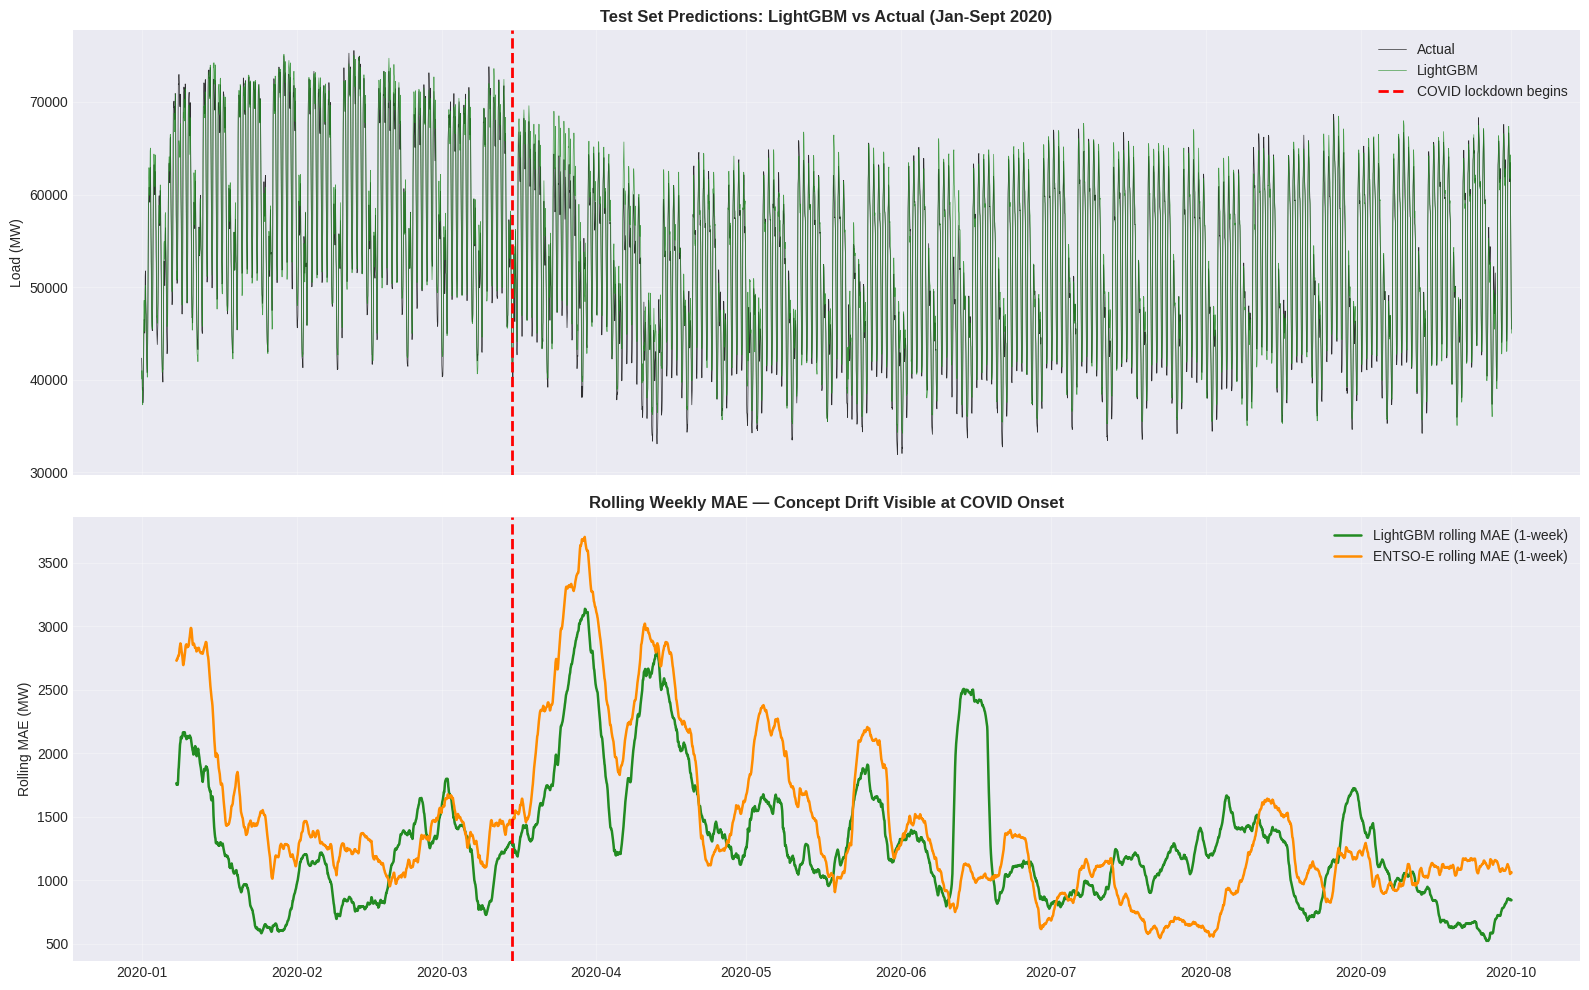


🔑 Look at the rolling MAE spike right after the red line — that's concept drift in action
🔑 The model that recovers fastest after the spike is the most adaptable


In [32]:
# Plot the test period with both models and highlight COVID
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: Actual vs LightGBM
axes[0].plot(test.index, y_test, color='black', linewidth=0.5, label='Actual', alpha=0.8)
axes[0].plot(test.index, y_test_pred_lgb, color='forestgreen', linewidth=0.5, label='LightGBM', alpha=0.8)
axes[0].axvline(covid_start, color='red', linestyle='--', linewidth=2, label='COVID lockdown begins')
axes[0].set_title('Test Set Predictions: LightGBM vs Actual (Jan-Sept 2020)', fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Bottom: Rolling weekly MAE for both models
window = 168  # 1 week
lgb_abs_err = (test_predictions_df['actual'] - test_predictions_df['lgb_pred']).abs()
entsoe_abs_err = (test_predictions_df['actual'] - test_predictions_df['entsoe_pred']).abs()

lgb_rolling = lgb_abs_err.rolling(window).mean()
entsoe_rolling = entsoe_abs_err.rolling(window).mean()

axes[1].plot(lgb_rolling.index, lgb_rolling.values, color='forestgreen', linewidth=1.8, label='LightGBM rolling MAE (1-week)')
axes[1].plot(entsoe_rolling.index, entsoe_rolling.values, color='darkorange', linewidth=1.8, label='ENTSO-E rolling MAE (1-week)')
axes[1].axvline(covid_start, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Rolling Weekly MAE — Concept Drift Visible at COVID Onset', fontweight='bold')
axes[1].set_ylabel('Rolling MAE (MW)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔑 Look at the rolling MAE spike right after the red line — that's concept drift in action")
print("🔑 The model that recovers fastest after the spike is the most adaptable")

In [34]:
def create_features_horizon(df, target_col='DE_load_actual_entsoe_transparency', min_lag_hours=24):
    """
    Build features that only use information available `min_lag_hours` before the target.
    For 24h ahead: use lags >= 24
    For 72h ahead: use lags >= 72
    For 168h ahead: use lags >= 168
    """
    X = df.copy()

    # Calendar features (always available)
    X['hour'] = X.index.hour
    X['dayofweek'] = X.index.dayofweek
    X['day'] = X.index.day
    X['month'] = X.index.month
    X['quarter'] = X.index.quarter
    X['dayofyear'] = X.index.dayofyear
    X['weekofyear'] = X.index.isocalendar().week.astype(int)
    X['is_weekend'] = (X['dayofweek'] >= 5).astype(int)

    # Cyclical encoding
    X['hour_sin'] = np.sin(2 * np.pi * X['hour'] / 24)
    X['hour_cos'] = np.cos(2 * np.pi * X['hour'] / 24)
    X['dayofweek_sin'] = np.sin(2 * np.pi * X['dayofweek'] / 7)
    X['dayofweek_cos'] = np.cos(2 * np.pi * X['dayofweek'] / 7)
    X['month_sin'] = np.sin(2 * np.pi * X['month'] / 12)
    X['month_cos'] = np.cos(2 * np.pi * X['month'] / 12)
    X['dayofyear_sin'] = np.sin(2 * np.pi * X['dayofyear'] / 365.25)
    X['dayofyear_cos'] = np.cos(2 * np.pi * X['dayofyear'] / 365.25)

    # Holidays (always available — known in advance)
    years = X.index.year.unique().tolist()
    de_holidays = holidays.Germany(years=years)
    X['is_holiday'] = X.index.normalize().to_series().apply(
        lambda d: 1 if d.date() in de_holidays else 0
    ).values
    X['is_day_before_holiday'] = X['is_holiday'].shift(-24).fillna(0).astype(int)
    X['is_day_after_holiday'] = X['is_holiday'].shift(24).fillna(0).astype(int)

    # Lag features — only use lags >= min_lag_hours
    for lag in [24, 48, 72, 168, 336]:
        if lag >= min_lag_hours:
            X[f'load_lag_{lag}h'] = X[target_col].shift(lag)

    # Rolling stats — shift by min_lag_hours to avoid leakage
    lagged = X[target_col].shift(min_lag_hours)
    X['load_rolling_mean_24h'] = lagged.rolling(window=24).mean()
    X['load_rolling_mean_168h'] = lagged.rolling(window=168).mean()
    X['load_rolling_std_24h'] = lagged.rolling(window=24).std()

    # Difference features
    if min_lag_hours <= 168:
        X['load_diff_168h'] = X[target_col].shift(168) - X[target_col].shift(336)

    return X


def train_horizon_model(horizon_hours, df, train_end, val_end):
    """Train and evaluate a LightGBM model for a specific forecast horizon."""
    print(f"\n{'='*60}")
    print(f"Training {horizon_hours}h-ahead model")
    print('='*60)

    df_h = create_features_horizon(df, min_lag_hours=horizon_hours)

    train_h = df_h.loc[:train_end].dropna()
    val_h = df_h.loc[train_end + pd.Timedelta(hours=1):val_end].copy()
    test_h = df_h.loc[val_end + pd.Timedelta(hours=1):].copy()

    feat_cols = [c for c in train_h.columns if c not in [
        target, 'DE_load_forecast_entsoe_transparency'
    ]]

    X_tr, y_tr = train_h[feat_cols], train_h[target]
    X_v, y_v = val_h[feat_cols], val_h[target]
    X_te, y_te = test_h[feat_cols], test_h[target]

    train_set = lgb.Dataset(X_tr, label=y_tr)
    val_set = lgb.Dataset(X_v, label=y_v, reference=train_set)

    model = lgb.train(
        lgb_params, train_set, num_boost_round=2000,
        valid_sets=[train_set, val_set], valid_names=['train', 'val'],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )

    val_pred = model.predict(X_v, num_iteration=model.best_iteration)
    test_pred = model.predict(X_te, num_iteration=model.best_iteration)

    val_mae = mean_absolute_error(y_v, val_pred)
    val_mape = np.mean(np.abs((y_v - val_pred) / y_v)) * 100
    test_mae = mean_absolute_error(y_te, test_pred)
    test_mape = np.mean(np.abs((y_te - test_pred) / y_te)) * 100

    print(f"  Validation: MAE = {val_mae:,.0f} MW | MAPE = {val_mape:.3f}%")
    print(f"  Test:       MAE = {test_mae:,.0f} MW | MAPE = {test_mape:.3f}%")

    return {
        'horizon': horizon_hours,
        'model': model,
        'features': feat_cols,
        'val_mae': val_mae, 'val_mape': val_mape,
        'test_mae': test_mae, 'test_mape': test_mape,
    }


# Train three horizon models
print("⏳ Training multi-horizon models — this will take a few minutes")
horizon_results = []
for h in [24, 72, 168]:
    horizon_results.append(train_horizon_model(h, df, train_end, val_end))

⏳ Training multi-horizon models — this will take a few minutes

Training 24h-ahead model
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[384]	train's l1: 488.773	val's l1: 1093.85
  Validation: MAE = 1,094 MW | MAPE = 2.018%
  Test:       MAE = 1,287 MW | MAPE = 2.502%

Training 72h-ahead model
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[451]	train's l1: 489.766	val's l1: 1357.49
  Validation: MAE = 1,357 MW | MAPE = 2.503%
  Test:       MAE = 1,645 MW | MAPE = 3.219%

Training 168h-ahead model
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[128]	train's l1: 867.105	val's l1: 1403.21
  Validation: MAE = 1,403 MW | MAPE = 2.586%
  Test:       MAE = 1,686 MW | MAPE = 3.301%


📊 Multi-Horizon Forecasting Results
  Horizon  Val MAE (MW)  Val MAPE (%)  Test MAE (MW)  Test MAPE (%)
 24h (1d)        1094.0         2.018         1287.0          2.502
 72h (3d)        1357.0         2.503         1645.0          3.219
168h (7d)        1403.0         2.586         1686.0          3.301


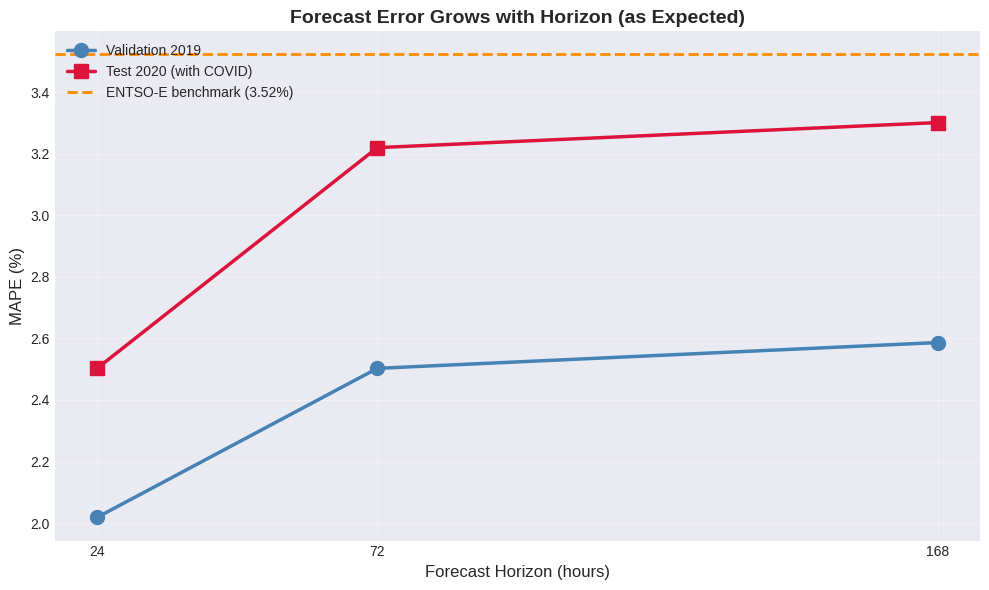


🔑 Error grows with horizon — this is the fundamental challenge of long-range forecasting
🔑 At 24h ahead, we beat ENTSO-E. At 168h ahead, error is higher but still useful.


In [35]:
# Build comparison dataframe
horizons_df = pd.DataFrame([{
    'Horizon': f'{r["horizon"]}h ({r["horizon"]//24}d)',
    'Val MAE (MW)': round(r['val_mae'], 0),
    'Val MAPE (%)': round(r['val_mape'], 3),
    'Test MAE (MW)': round(r['test_mae'], 0),
    'Test MAPE (%)': round(r['test_mape'], 3),
} for r in horizon_results])

print("📊 Multi-Horizon Forecasting Results")
print("=" * 70)
print(horizons_df.to_string(index=False))
print("=" * 70)

# Visualize the error growth with horizon
fig, ax = plt.subplots(figsize=(10, 6))
horizons = [r['horizon'] for r in horizon_results]
val_mapes = [r['val_mape'] for r in horizon_results]
test_mapes = [r['test_mape'] for r in horizon_results]

ax.plot(horizons, val_mapes, 'o-', linewidth=2.5, markersize=10, color='steelblue', label='Validation 2019')
ax.plot(horizons, test_mapes, 's-', linewidth=2.5, markersize=10, color='crimson', label='Test 2020 (with COVID)')
ax.axhline(3.522, color='darkorange', linestyle='--', linewidth=2, label='ENTSO-E benchmark (3.52%)')

ax.set_xlabel('Forecast Horizon (hours)', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('Forecast Error Grows with Horizon (as Expected)', fontsize=14, fontweight='bold')
ax.set_xticks(horizons)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🔑 Error grows with horizon — this is the fundamental challenge of long-range forecasting")
print("🔑 At 24h ahead, we beat ENTSO-E. At 168h ahead, error is higher but still useful.")

In [36]:
# Train quantile models for 10th and 90th percentiles (80% prediction interval)
# We use the 24h-ahead feature setup for this demo

df_24h = create_features_horizon(df, min_lag_hours=24)
train_24h = df_24h.loc[:train_end].dropna()
val_24h = df_24h.loc[train_end + pd.Timedelta(hours=1):val_end].copy()

feat_cols_24h = horizon_results[0]['features']
X_tr_24h = train_24h[feat_cols_24h]
y_tr_24h = train_24h[target]
X_v_24h = val_24h[feat_cols_24h]
y_v_24h = val_24h[target]

# Quantile params for lower bound (10th percentile)
lower_params = lgb_params.copy()
lower_params.update({'objective': 'quantile', 'alpha': 0.10, 'metric': 'quantile'})

# Quantile params for upper bound (90th percentile)
upper_params = lgb_params.copy()
upper_params.update({'objective': 'quantile', 'alpha': 0.90, 'metric': 'quantile'})

print("⏳ Training lower quantile (10th percentile) model...")
train_set_q = lgb.Dataset(X_tr_24h, label=y_tr_24h)
val_set_q = lgb.Dataset(X_v_24h, label=y_v_24h, reference=train_set_q)

model_lower = lgb.train(
    lower_params, train_set_q, num_boost_round=2000,
    valid_sets=[train_set_q, val_set_q], valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

print("⏳ Training upper quantile (90th percentile) model...")
model_upper = lgb.train(
    upper_params, train_set_q, num_boost_round=2000,
    valid_sets=[train_set_q, val_set_q], valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)

# Predict intervals on validation
pred_lower = model_lower.predict(X_v_24h, num_iteration=model_lower.best_iteration)
pred_upper = model_upper.predict(X_v_24h, num_iteration=model_upper.best_iteration)
pred_median = horizon_results[0]['model'].predict(X_v_24h, num_iteration=horizon_results[0]['model'].best_iteration)

# Coverage check: what % of actuals fall within our 80% interval?
within_interval = ((y_v_24h.values >= pred_lower) & (y_v_24h.values <= pred_upper))
coverage = within_interval.mean() * 100
avg_width = (pred_upper - pred_lower).mean()

print(f"\n📊 Prediction Interval Quality (target: 80% coverage)")
print(f"   Actual coverage:    {coverage:.1f}%   ({'✅ well-calibrated' if 75 <= coverage <= 85 else '⚠️ recalibration needed'})")
print(f"   Average width:      {avg_width:,.0f} MW")
print(f"   Mean load:          {y_v_24h.mean():,.0f} MW")
print(f"   Relative width:     {100 * avg_width / y_v_24h.mean():.1f}% of mean load")

⏳ Training lower quantile (10th percentile) model...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[185]	train's quantile: 180.578	val's quantile: 321.717
⏳ Training upper quantile (90th percentile) model...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[553]	train's quantile: 122.278	val's quantile: 266.653

📊 Prediction Interval Quality (target: 80% coverage)
   Actual coverage:    62.1%   (⚠️ recalibration needed)
   Average width:      2,784 MW
   Mean load:          55,990 MW
   Relative width:     5.0% of mean load


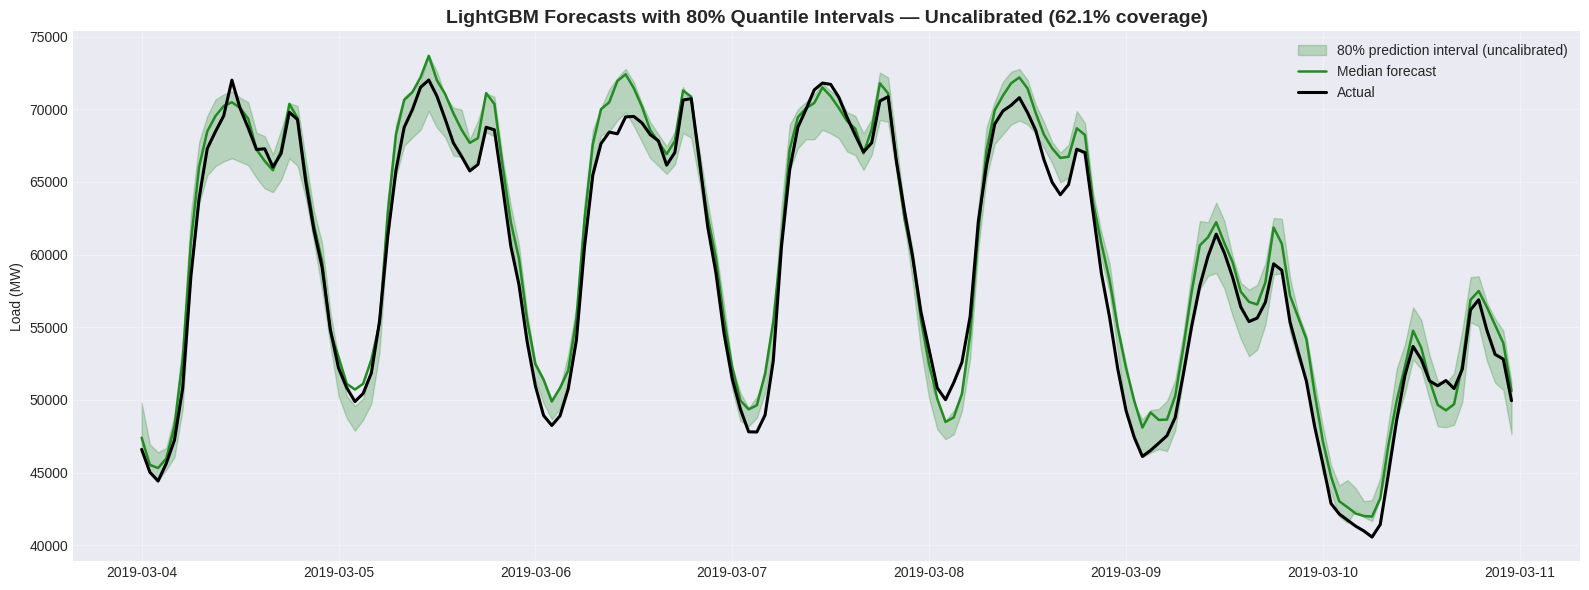

In [38]:
# Plot one week of predictions with intervals
sample_start = pd.Timestamp('2019-03-04', tz=tz)
sample_end = pd.Timestamp('2019-03-10 23:00', tz=tz)

sample_mask = (val_24h.index >= sample_start) & (val_24h.index <= sample_end)
sample_idx = val_24h.loc[sample_mask].index

sample_actual = val_24h.loc[sample_mask, target].values
sample_lower = pred_lower[sample_mask]
sample_upper = pred_upper[sample_mask]
sample_median = pred_median[sample_mask]

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(sample_idx, sample_lower, sample_upper,
                color='forestgreen', alpha=0.25, label='80% prediction interval (uncalibrated)')
ax.plot(sample_idx, sample_median, color='forestgreen', linewidth=1.8,
        label='Median forecast', zorder=4)
ax.plot(sample_idx, sample_actual, color='black', linewidth=2.2,
        label='Actual', zorder=5)

ax.set_title('LightGBM Forecasts with 80% Quantile Intervals — Uncalibrated (62.1% coverage)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right', framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Split validation into two halves: calibration set + true validation set
# We'll use the first half to measure residuals, second half to evaluate coverage

n_val = len(X_v_24h)
split_point = n_val // 2

# Calibration set (first half of validation)
X_cal = X_v_24h.iloc[:split_point]
y_cal = y_v_24h.iloc[:split_point]

# True validation set (second half — completely held out)
X_eval = X_v_24h.iloc[split_point:]
y_eval = y_v_24h.iloc[split_point:]

# Get predictions on calibration set
cal_lower = model_lower.predict(X_cal, num_iteration=model_lower.best_iteration)
cal_upper = model_upper.predict(X_cal, num_iteration=model_upper.best_iteration)

# Compute conformity scores: how far outside the interval each true value was
# Score is positive if y is outside the interval, negative if inside
cal_scores = np.maximum(cal_lower - y_cal.values, y_cal.values - cal_upper)

# For 80% coverage, take the 80th percentile of conformity scores
# (with finite-sample correction)
n_cal = len(cal_scores)
alpha = 0.20  # 1 - target coverage
q_level = np.ceil((n_cal + 1) * (1 - alpha)) / n_cal
q_hat = np.quantile(cal_scores, q_level)

print(f"📊 Conformal Calibration")
print(f"   Calibration set size: {n_cal:,}")
print(f"   Quantile level:       {q_level:.4f}")
print(f"   Calibration offset:   {q_hat:,.0f} MW (added/subtracted from quantile predictions)")

# Apply conformal correction on the held-out eval set
eval_lower_raw = model_lower.predict(X_eval, num_iteration=model_lower.best_iteration)
eval_upper_raw = model_upper.predict(X_eval, num_iteration=model_upper.best_iteration)

eval_lower_conf = eval_lower_raw - q_hat
eval_upper_conf = eval_upper_raw + q_hat

# Check coverage of calibrated intervals
within_raw = ((y_eval.values >= eval_lower_raw) & (y_eval.values <= eval_upper_raw))
within_conf = ((y_eval.values >= eval_lower_conf) & (y_eval.values <= eval_upper_conf))

cov_raw = within_raw.mean() * 100
cov_conf = within_conf.mean() * 100
width_raw = (eval_upper_raw - eval_lower_raw).mean()
width_conf = (eval_upper_conf - eval_lower_conf).mean()

print(f"\n📊 Coverage Comparison on Held-Out Evaluation Set")
print(f"   Target coverage: 80%")
print(f"\n   {'Method':<25} {'Coverage':>12} {'Avg Width':>15}")
print(f"   {'─'*55}")
print(f"   {'Uncalibrated (quantile)':<25} {cov_raw:>11.1f}% {width_raw:>12,.0f} MW")
print(f"   {'Conformal-calibrated':<25} {cov_conf:>11.1f}% {width_conf:>12,.0f} MW")
print(f"\n🔑 Conformal prediction provides distribution-free coverage guarantees")
print(f"🔑 We trade slightly wider intervals for honest, reliable uncertainty quantification")

📊 Conformal Calibration
   Calibration set size: 4,380
   Quantile level:       0.8002
   Calibration offset:   565 MW (added/subtracted from quantile predictions)

📊 Coverage Comparison on Held-Out Evaluation Set
   Target coverage: 80%

   Method                        Coverage       Avg Width
   ───────────────────────────────────────────────────────
   Uncalibrated (quantile)          61.2%        2,455 MW
   Conformal-calibrated             81.4%        3,585 MW

🔑 Conformal prediction provides distribution-free coverage guarantees
🔑 We trade slightly wider intervals for honest, reliable uncertainty quantification


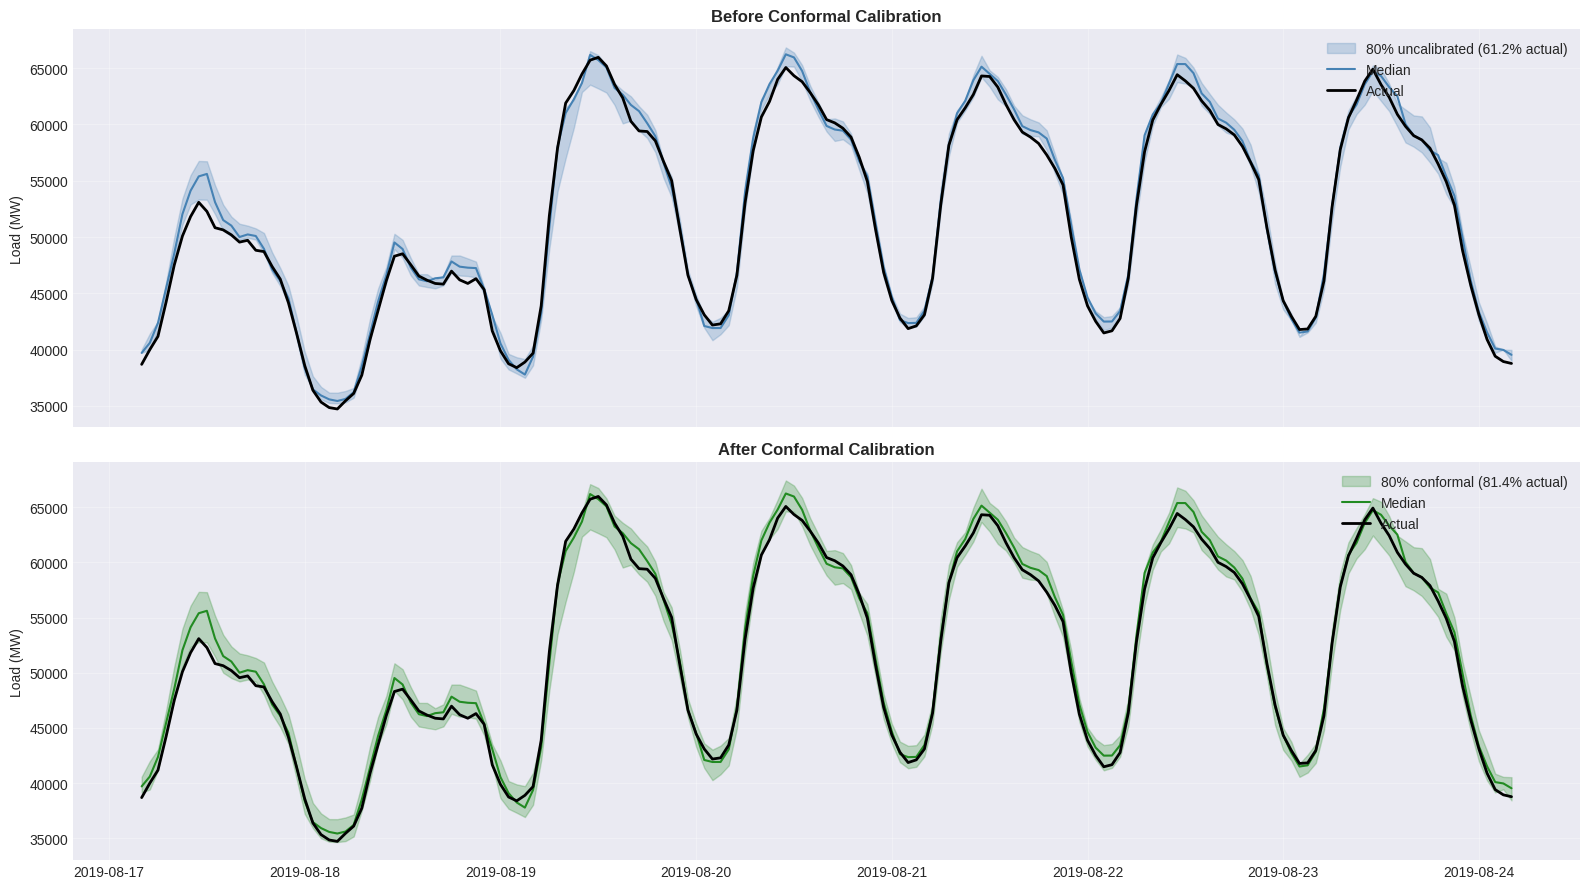

In [40]:
# Plot both intervals side-by-side on a sample week from eval set
eval_idx = X_eval.index
sample_start_2 = eval_idx[len(eval_idx) // 4]
sample_end_2 = sample_start_2 + pd.Timedelta(days=7)

mask_2 = (eval_idx >= sample_start_2) & (eval_idx <= sample_end_2)
idx_2 = eval_idx[mask_2]

# Median predictions on eval set
eval_median = horizon_results[0]['model'].predict(X_eval, num_iteration=horizon_results[0]['model'].best_iteration)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Uncalibrated
axes[0].fill_between(idx_2, eval_lower_raw[mask_2], eval_upper_raw[mask_2],
                     color='steelblue', alpha=0.25, label=f'80% uncalibrated ({cov_raw:.1f}% actual)')
axes[0].plot(idx_2, eval_median[mask_2], color='steelblue', linewidth=1.5, label='Median')
axes[0].plot(idx_2, y_eval.values[mask_2], color='black', linewidth=2, label='Actual', zorder=5)
axes[0].set_title('Before Conformal Calibration', fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Calibrated
axes[1].fill_between(idx_2, eval_lower_conf[mask_2], eval_upper_conf[mask_2],
                     color='forestgreen', alpha=0.25, label=f'80% conformal ({cov_conf:.1f}% actual)')
axes[1].plot(idx_2, eval_median[mask_2], color='forestgreen', linewidth=1.5, label='Median')
axes[1].plot(idx_2, y_eval.values[mask_2], color='black', linewidth=2, label='Actual', zorder=5)
axes[1].set_title('After Conformal Calibration', fontweight='bold')
axes[1].set_ylabel('Load (MW)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
!pip install -q shap

In [42]:
import shap

# SHAP can be expensive on full datasets — sample 2000 rows from validation for speed
# We use the strict 24h-ahead model since that's our primary deliverable
sample_size = 2000
np.random.seed(42)
sample_idx = np.random.choice(len(X_v_24h), size=sample_size, replace=False)
X_shap = X_v_24h.iloc[sample_idx]

print(f"⏳ Computing SHAP values on {sample_size} validation samples...")
print(f"   This takes ~30-60 seconds for LightGBM")

# TreeExplainer is the fast path for tree-based models
model_24h = horizon_results[0]['model']
explainer = shap.TreeExplainer(model_24h)
shap_values = explainer.shap_values(X_shap)

print(f"✅ Done. SHAP values shape: {shap_values.shape}")
print(f"   Expected value (baseline prediction): {explainer.expected_value:,.0f} MW")

⏳ Computing SHAP values on 2000 validation samples...
   This takes ~30-60 seconds for LightGBM
✅ Done. SHAP values shape: (2000, 32)
   Expected value (baseline prediction): 55,839 MW


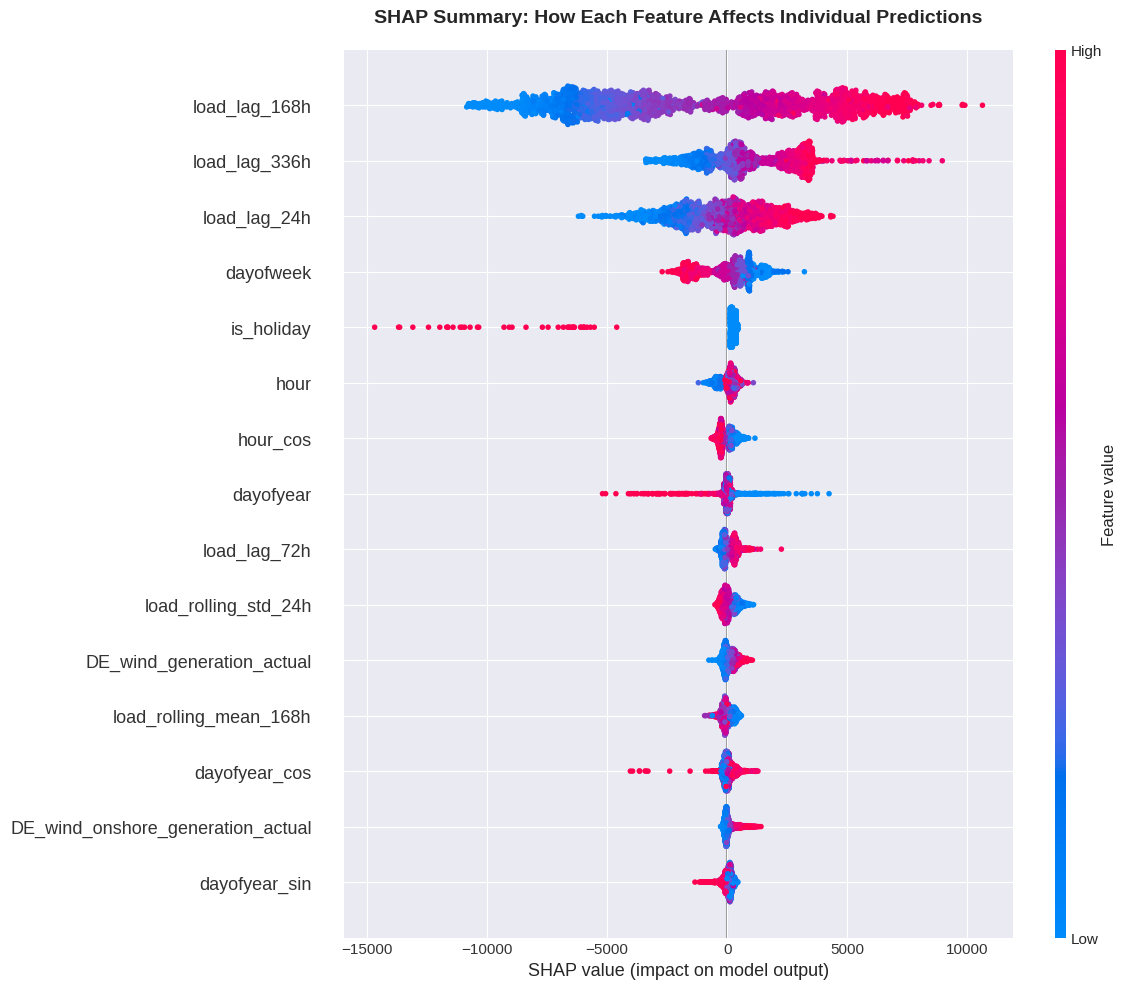


🔑 How to read this plot:
   • Y-axis: features ranked by overall importance
   • X-axis: SHAP value (impact on prediction, in MW)
   • Color: feature value (red = high, blue = low)
   • Each dot = one prediction

   Example interpretation for load_lag_168h:
     Red dots on the right → high load last week → predicts high load now
     Blue dots on the left → low load last week → predicts low load now
     This linear pattern = the feature has a clean, monotonic effect


In [43]:
# Beeswarm plot — the iconic SHAP visualization
# Shows feature importance AND directionality AND value distributions in one plot

fig = plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values, X_shap,
    max_display=15,
    show=False,
    plot_size=(12, 10),
)
plt.title('SHAP Summary: How Each Feature Affects Individual Predictions',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n🔑 How to read this plot:")
print("   • Y-axis: features ranked by overall importance")
print("   • X-axis: SHAP value (impact on prediction, in MW)")
print("   • Color: feature value (red = high, blue = low)")
print("   • Each dot = one prediction")
print("")
print("   Example interpretation for load_lag_168h:")
print("     Red dots on the right → high load last week → predicts high load now")
print("     Blue dots on the left → low load last week → predicts low load now")
print("     This linear pattern = the feature has a clean, monotonic effect")

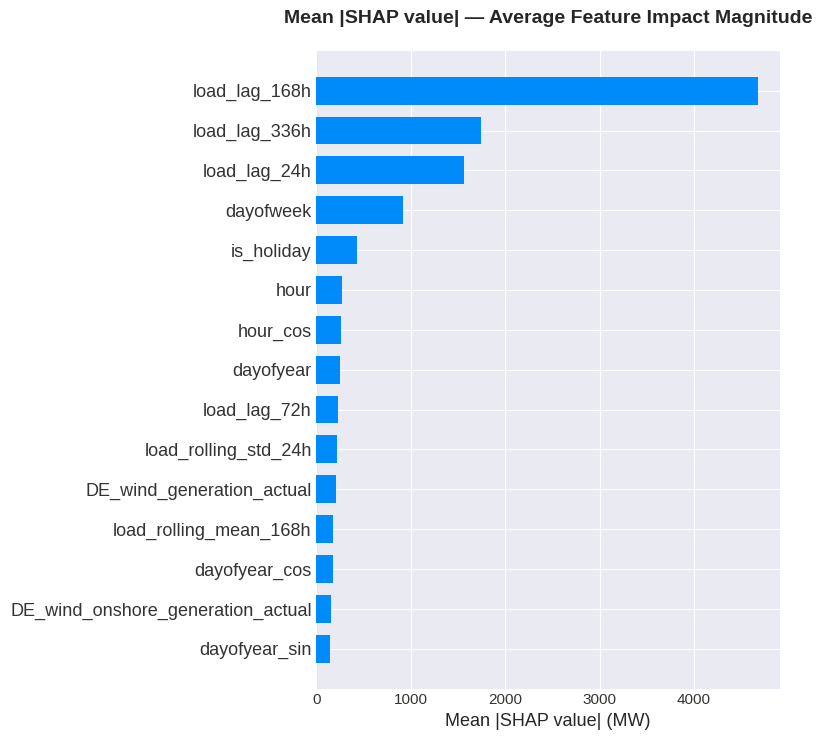

In [44]:
# Mean absolute SHAP values — cleaner for README presentation
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.title('Mean |SHAP value| — Average Feature Impact Magnitude',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP value| (MW)')
plt.tight_layout()
plt.savefig('results/shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

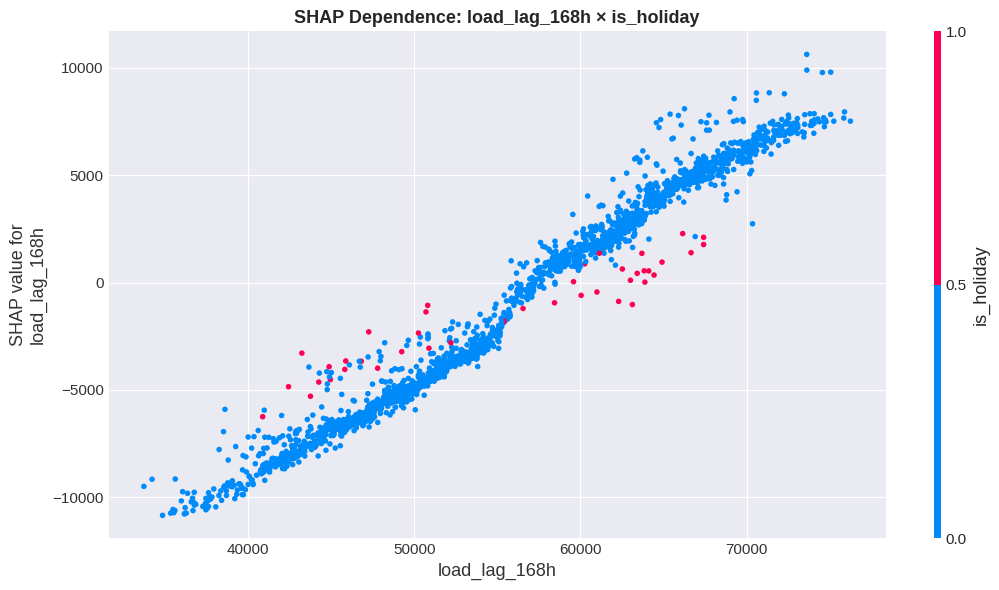


🔑 The diagonal pattern shows: higher load last week → higher predicted load now
🔑 Color (is_holiday) shows interaction: holiday effect on top of the lag relationship


In [45]:
# Dependence plot for the most important feature
fig, ax = plt.subplots(figsize=(11, 6))
shap.dependence_plot(
    'load_lag_168h',
    shap_values, X_shap,
    interaction_index='is_holiday',
    ax=ax, show=False,
)
ax.set_title('SHAP Dependence: load_lag_168h × is_holiday',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/shap_dependence_lag168.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n🔑 The diagonal pattern shows: higher load last week → higher predicted load now")
print("🔑 Color (is_holiday) shows interaction: holiday effect on top of the lag relationship")

📍 Explaining prediction for: 2019-12-25 18:00:00+01:00
   Actual load:    48,297 MW
   Predicted load: 49,912 MW
   Error:          1,615 MW (3.34%)
   Baseline:       55,839 MW (mean training prediction)


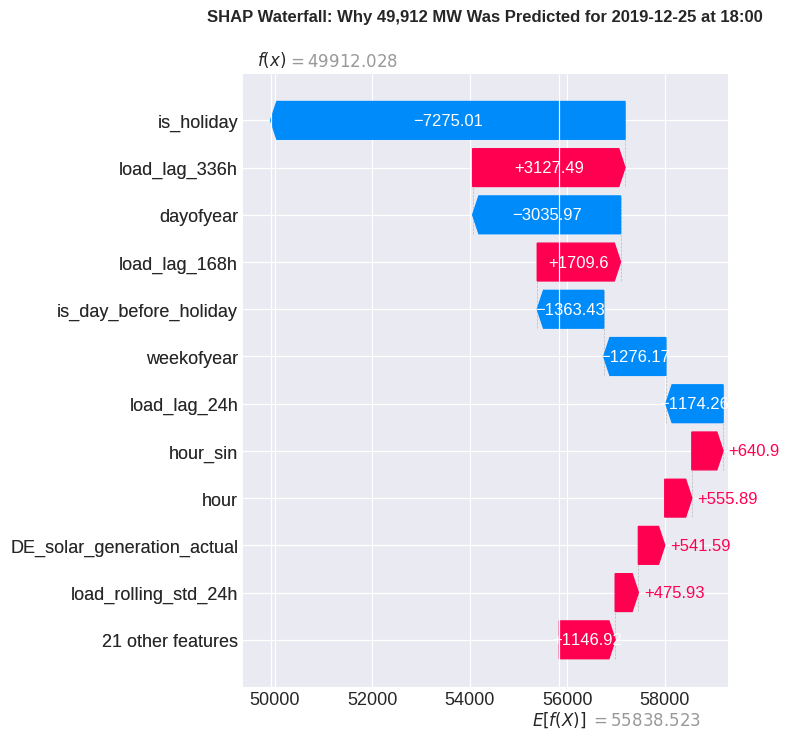


🔑 Red bars = features that increased the prediction above baseline
🔑 Blue bars = features that decreased the prediction
🔑 For Christmas Day, watch the is_holiday feature push prediction DOWN ↓


In [46]:
# Pick a single prediction to explain in detail
# Let's use a Christmas Day prediction to see the holiday effect at work
christmas_2019 = pd.Timestamp('2019-12-25 18:00', tz=tz)

# Find the row in our sample (or use the actual val_24h row)
single_row = X_v_24h.loc[[christmas_2019]] if christmas_2019 in X_v_24h.index else X_v_24h.iloc[[100]]
single_actual = y_v_24h.loc[single_row.index].values[0]
single_pred = model_24h.predict(single_row, num_iteration=model_24h.best_iteration)[0]

# Compute SHAP values for this single prediction
single_shap = explainer.shap_values(single_row)

print(f"📍 Explaining prediction for: {single_row.index[0]}")
print(f"   Actual load:    {single_actual:,.0f} MW")
print(f"   Predicted load: {single_pred:,.0f} MW")
print(f"   Error:          {abs(single_actual - single_pred):,.0f} MW ({100*abs(single_actual-single_pred)/single_actual:.2f}%)")
print(f"   Baseline:       {explainer.expected_value:,.0f} MW (mean training prediction)")

# Waterfall plot — shows how each feature pushed prediction from baseline to final
fig = plt.figure(figsize=(12, 8))
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    single_shap[0],
    feature_names=single_row.columns.tolist(),
    max_display=12,
    show=False,
)
plt.title(f'SHAP Waterfall: Why {single_pred:,.0f} MW Was Predicted for {single_row.index[0].date()} at {single_row.index[0].hour}:00',
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/shap_waterfall_christmas.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n🔑 Red bars = features that increased the prediction above baseline")
print("🔑 Blue bars = features that decreased the prediction")
print("🔑 For Christmas Day, watch the is_holiday feature push prediction DOWN ↓")

In [47]:
import pickle

os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Save the trained models
model_24h.save_model('models/lightgbm_24h.txt')
horizon_results[1]['model'].save_model('models/lightgbm_72h.txt')
horizon_results[2]['model'].save_model('models/lightgbm_168h.txt')
model_lower.save_model('models/lightgbm_quantile_lower.txt')
model_upper.save_model('models/lightgbm_quantile_upper.txt')

# Save conformal calibration offset
with open('models/conformal_offset.pkl', 'wb') as f:
    pickle.dump({'q_hat': float(q_hat), 'target_coverage': 0.80}, f)

# Save final metrics summary
final_metrics = pd.DataFrame({
    'Model': ['Seasonal Naive', 'ENTSO-E Forecast', 'LightGBM 24h', 'LightGBM 72h', 'LightGBM 168h'],
    'Val MAE (MW)': [snaive_metrics['MAE (MW)'], entsoe_metrics['MAE (MW)'],
                     horizon_results[0]['val_mae'], horizon_results[1]['val_mae'], horizon_results[2]['val_mae']],
    'Val MAPE (%)': [snaive_metrics['MAPE (%)'], entsoe_metrics['MAPE (%)'],
                     horizon_results[0]['val_mape'], horizon_results[1]['val_mape'], horizon_results[2]['val_mape']],
    'Test MAE (MW)': [np.nan, np.nan,
                      horizon_results[0]['test_mae'], horizon_results[1]['test_mae'], horizon_results[2]['test_mae']],
    'Test MAPE (%)': [np.nan, np.nan,
                      horizon_results[0]['test_mape'], horizon_results[1]['test_mape'], horizon_results[2]['test_mape']],
})
final_metrics.to_csv('results/final_metrics.csv', index=False)

print("📁 Saved to /content/:")
print("   models/")
print("     lightgbm_24h.txt, lightgbm_72h.txt, lightgbm_168h.txt")
print("     lightgbm_quantile_lower.txt, lightgbm_quantile_upper.txt")
print("     conformal_offset.pkl")
print("   results/")
print("     final_metrics.csv")
print("     shap_summary.png, shap_bar.png")
print("     shap_dependence_lag168.png, shap_waterfall_christmas.png")
print("\n📊 Final metrics summary:")
print(final_metrics.to_string(index=False))

📁 Saved to /content/:
   models/
     lightgbm_24h.txt, lightgbm_72h.txt, lightgbm_168h.txt
     lightgbm_quantile_lower.txt, lightgbm_quantile_upper.txt
     conformal_offset.pkl
   results/
     final_metrics.csv
     shap_summary.png, shap_bar.png
     shap_dependence_lag168.png, shap_waterfall_christmas.png

📊 Final metrics summary:
           Model  Val MAE (MW)  Val MAPE (%)  Test MAE (MW)  Test MAPE (%)
  Seasonal Naive   2558.000000      4.735000            NaN            NaN
ENTSO-E Forecast   1988.920000      3.522000            NaN            NaN
    LightGBM 24h   1093.845649      2.018329    1286.926516       2.502137
    LightGBM 72h   1357.490897      2.502537    1644.976136       3.219384
   LightGBM 168h   1403.210319      2.586384    1686.214487       3.300881
